# 07 · SVM ve Kernel Trick (Support Vector Machines & the Kernel Trick)
**Classical ML Lab** · Marj Maksimizasyonu ve Yüksek Boyutlu Uzaylarda Doğrusal Ayrım

---
> **Bu notebook'ta ne öğreneceğiz?**
> Şimdiye kadar gördüğümüz sınıflandırıcılar ya olasılıksal bir model kurdu (`06_naive_bayes_family`: $P(x\mid y)$'yi tahmin edip Bayes teoremiyle ters çevirme) ya da doğrudan bir karar sınırı öğrendi (`03_linear_classification_family`: Lojistik Regresyon, LDA/QDA). **Support Vector Machine (SVM)**, üçüncü ve tamamen farklı bir felsefeyle yaklaşır: olasılık hiç hesaplamadan, sadece **iki sınıf arasındaki boşluğu (marjı) mümkün olduğunca genişleten** bir hiper-düzlem arar. Bu basit geometrik fikir, **kernel trick** ile birleştiğinde SVM'i 1990'lar-2000'ler arasında (derin öğrenmeden önce) görüntü tanıma, biyoinformatik ve metin sınıflandırmada devlet-of-the-art yapan güçlü bir araca dönüştürür: veriyi hiç açıkça yüksek boyuta taşımadan, sanki taşınmış gibi doğrusal olmayan sınır öğrenebiliriz. Bu notebook'ta: (1) maksimum marj ve destek vektörü (support vector) kavramını sıfırdan inşa edeceğiz, (2) soft margin ile gürültülü/örtüşen veriye tolerans kazandıracağız, (3) kernel trick'in matematiğini (linear/polynomial/RBF/sigmoid) ve "neden işe yaradığını" XOR gibi somut bir örnekle görselleştireceğiz, (4) SVC (sınıflandırma) ve SVR (regresyon) varyantlarını üç farklı gerçek veri setinde uygulayacağız, ve (5) ölçeklemenin (feature scaling) SVM için neden **kritik** olduğunu ampirik olarak göstereceğiz.
>
> **Önkoşul:** `03_linear_classification_family` (doğrusal karar sınırları, çok sınıflı stratejiler), temel lineer cebir (iç çarpım/dot product, norm).
> **Veri:** UCI Wheat Seeds (buğday tanesi/kernel çeşidi sınıflandırma — 3 sınıf), UCI Banknote Authentication (sahte para tespiti — ikili), UCI Abalone (deniz kulağı yaşı tahmini — regresyon), ayrıca kernel trick'i görselleştirmek için sentetik 2B veri (`make_circles`, `make_moons`, XOR).
> **Araçlar:** Python (`scikit-learn` — `SVC`, `SVR`, `LinearSVC`), R (`e1071::svm`), SQL (DuckDB — karar fonksiyonunun destek vektörlerinden yeniden üretimi).

---
## 1 · Maksimum Marj Sınıflandırıcısı (Maximal Margin Classifier)

İki sınıfın doğrusal olarak ayrılabildiği (linearly separable) bir veri setinde, sınıfları ayıran **sonsuz sayıda** hiper-düzlem vardır. SVM'in temel sorusu: hangisini seçmeliyiz? Sezgisel cevap — **her iki sınıftan da mümkün olduğunca uzak duran** hiper-düzlemi seçmek, çünkü bu, görülmemiş (test) verideki küçük gürültüye karşı en dayanıklı (robust) sınırı verir.

Bir hiper-düzlem $w^T x + b = 0$ ile tanımlanır ($w$ normal vektör, $b$ bias/intercept). Bir noktanın hiper-düzleme **imzalı uzaklığı**:
$$d(x) = \frac{w^T x + b}{\|w\|}$$

**Marj (margin)**, hiper-düzlemden her iki sınıftaki en yakın noktalara olan uzaklıktır. Bu en yakın noktalara **destek vektörleri (support vectors)** denir — isim buradan gelir: sınırı yalnızca bu noktalar "destekler" (belirler), diğer tüm noktalar sınırın konumunu değiştirmeden kaldırılabilir. Bu, SVM'i k-NN gibi tüm veriye bağımlı yöntemlerden ayıran kritik özelliktir: **model, eğitim verisinin küçük bir alt kümesiyle (destek vektörleriyle) tamamen özetlenir.**

Etiketleri $y_i \in \{-1, +1\}$ alırsak (SVM'in klasik gösterimi — Lojistik Regresyon'daki $\{0,1\}$'den farklı), "doğru sınıflandırma" koşulu $y_i(w^T x_i + b) > 0$ olur. Marjı $M$ olacak şekilde ölçeklersek ($w,b$'yi $\|w\|=1/M$ olacak şekilde normalize ederek), **hard-margin SVM** optimizasyon problemi:
$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{öyle ki} \quad y_i(w^T x_i + b) \geq 1 \quad \forall i$$

$\|w\|^2$'yi minimize etmek marjı ($M = 1/\|w\|$) maksimize etmeye denktir — bu **dışbükey (convex) ikinci dereceden bir optimizasyon problemi (Quadratic Programming, QP)** olduğundan, yerel minimuma takılma riski olmadan **global optimum** garantilidir (Lojistik Regresyon'un gradyan inişiyle bulduğu çözümden farklı olarak, SVM'in çözümü kapalı bir QP formülasyonuyla bulunur).

**Endüstride nerede kullanılır?** Maksimum marj fikri doğrudan pratik değer taşır: kredi skorlama sistemlerinde, karar sınırının eğitim verisine "ezberlenmeden" mümkün olduğunca geniş bir güvenlik boşluğuyla çizilmesi, sınır civarındaki (borderline) yeni başvurularda daha kararlı (stabil) kararlar üretir — bu, düzenleyici kurumların (regulator) istediği "tutarlılık" özelliğine katkı sağlar.

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
)
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.linear_model import LinearRegression
import duckdb
import time
import warnings

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)


### Marjı elle görselleştirelim (basit, doğrusal ayrılabilir sentetik veri)

Yukarıdaki formülü somutlaştırmak için, `scikit-learn`'ün `SVC(kernel='linear')`'ını doğrusal ayrılabilir 2B bir veri setine uygulayıp hiper-düzlemi, marjı ve destek vektörlerini çizelim.

w = [-0.01682321 -0.89425662], b = -5.341
||w|| = 0.8944  ->  Marj M = 1/||w|| = 1.1180
Destek vektörü sayısı: [2 1] (sınıf başına)


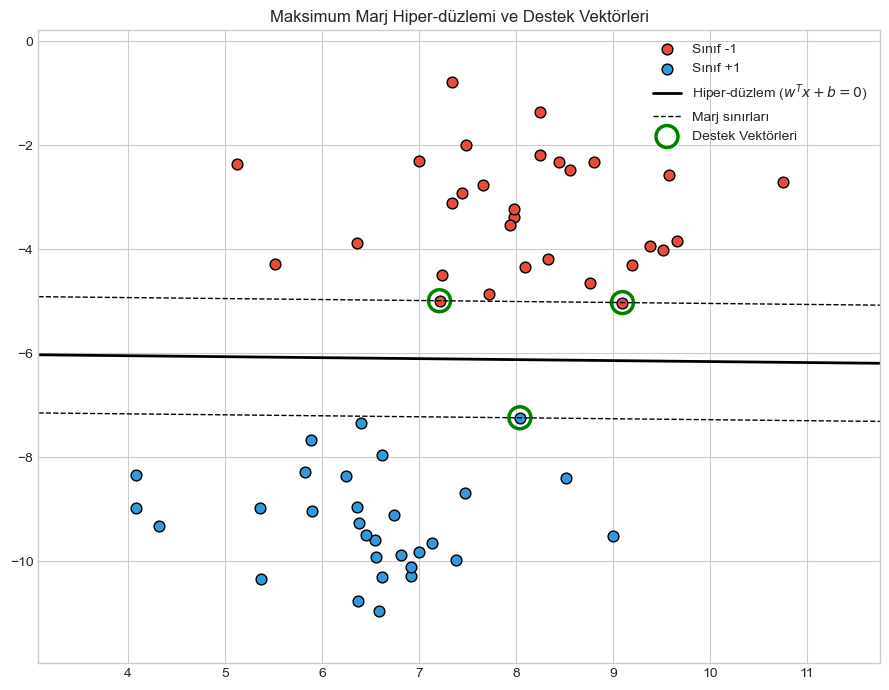


YORUM: Hiper-düzlem, sadece yeşille işaretli destek vektörlerinin konumuna bağlıdır.
Diğer noktalardan herhangi biri (marjın dışında kalan) veri setinden çıkarılsa,
hiper-düzlem ve marj HİÇ değişmez -- bu, SVM'in 'seyrek' (sparse) bir model olduğunun kanıtıdır.


In [108]:
X_toy, y_toy = make_blobs(n_samples=60, centers=2, cluster_std=1.1, random_state=6)  
y_toy_pm = np.where(y_toy == 0, -1, 1)  # {-1, +1} gösterimi

svm_toy = SVC(kernel='linear', C=1000)  # büyük C -> hard-margin'e yakın
svm_toy.fit(X_toy, y_toy_pm)

w = svm_toy.coef_[0]
b = svm_toy.intercept_[0]
print(f"w = {w}, b = {b:.3f}")
print(f"||w|| = {np.linalg.norm(w):.4f}  ->  Marj M = 1/||w|| = {1/np.linalg.norm(w):.4f}")
print(f"Destek vektörü sayısı: {svm_toy.n_support_} (sınıf başına)")

xx = np.linspace(X_toy[:, 0].min() - 1, X_toy[:, 0].max() + 1, 200)
yy_boundary = -(w[0] * xx + b) / w[1]
margin = 1 / np.linalg.norm(w)
yy_up = yy_boundary + margin * np.sqrt(1 + (w[0] / w[1]) ** 2)
yy_down = yy_boundary - margin * np.sqrt(1 + (w[0] / w[1]) ** 2)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_toy[y_toy_pm == -1, 0], X_toy[y_toy_pm == -1, 1], c='#e74c3c', label='Sınıf -1', edgecolor='k', s=60)
ax.scatter(X_toy[y_toy_pm == 1, 0], X_toy[y_toy_pm == 1, 1], c='#3498db', label='Sınıf +1', edgecolor='k', s=60)
ax.plot(xx, yy_boundary, 'k-', linewidth=2, label='Hiper-düzlem ($w^Tx+b=0$)')
ax.plot(xx, yy_up, 'k--', linewidth=1, label='Marj sınırları')
ax.plot(xx, yy_down, 'k--', linewidth=1)
ax.scatter(svm_toy.support_vectors_[:, 0], svm_toy.support_vectors_[:, 1],
           s=250, facecolors='none', edgecolors='green', linewidth=2.5, label='Destek Vektörleri')
ax.set_xlim(X_toy[:, 0].min() - 1, X_toy[:, 0].max() + 1)
ax.set_ylim(X_toy[:, 1].min() - 1, X_toy[:, 1].max() + 1)
ax.set_title('Maksimum Marj Hiper-düzlemi ve Destek Vektörleri')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

print("\nYORUM: Hiper-düzlem, sadece yeşille işaretli destek vektörlerinin konumuna bağlıdır.")
print("Diğer noktalardan herhangi biri (marjın dışında kalan) veri setinden çıkarılsa,")
print("hiper-düzlem ve marj HİÇ değişmez -- bu, SVM'in 'seyrek' (sparse) bir model olduğunun kanıtıdır.")


---
## 2 · Soft Margin ve C Hiperparametresi

Gerçek veri neredeyse hiçbir zaman mükemmel doğrusal ayrılabilir değildir — örtüşen sınıflar, aykırı değerler (outlier), gürültü kaçınılmazdır. Hard-margin SVM böyle bir veride **çözümsüz** kalır (kısıtları sağlayan hiçbir $w,b$ yoktur). Çözüm: her nokta için bir **gevşeklik değişkeni (slack variable)** $\xi_i \geq 0$ tanımlayıp, bazı noktaların marjın içine sızmasına ya da yanlış sınıflandırılmasına **izin verip cezalandırmak**:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i \quad \text{öyle ki} \quad y_i(w^Tx_i+b) \geq 1-\xi_i,\ \ \xi_i \geq 0$$

$C > 0$, marj genişliği ile yanlış sınıflandırma cezası arasındaki **ödünleşimi (trade-off)** kontrol eder:
- **Küçük $C$** → ceza hafif → geniş marj, daha fazla noktanın sızmasına izin verilir → **yüksek bias, düşük varyans** (basit/genelleyici model, düzenlileştirme güçlü).
- **Büyük $C$** → ceza ağır → dar marj, eğitim hatasını minimize etmeye öncelik → **düşük bias, yüksek varyans** (karmaşık/ezberleyici model, aşırı öğrenmeye — overfitting — yatkın).

Bu problem eşdeğer olarak **hinge loss + L2 düzenlileştirme** şeklinde de yazılabilir:
$$\min_{w,b} \ \underbrace{\frac{1}{2}\|w\|^2}_{\text{düzenlileştirme}} + C\sum_{i=1}^n \underbrace{\max(0,\ 1-y_i(w^Tx_i+b))}_{\text{hinge loss}}$$

Hinge loss, bir noktayı yalnızca **marjın içindeyse veya yanlış tarafındaysa** cezalandırır (doğru sınıflandırılmış ve marjın dışındaki noktalar için kayıp tam olarak $0$'dır) — bu da destek-vektörü-dışı noktaların optimizasyona hiç katkı vermemesinin (yani modelin seyrekliğinin) cebirsel kökenidir. Bu, Lojistik Regresyon'un log-loss'una (hiçbir zaman tam sıfıra inmeyen, tüm noktaları hafifçe cezalandırmaya devam eden) göre temel bir farktır.

**Dual problem:** Pratikte SVM, yukarıdaki "primal" formdan ziyade **Lagrange dual** formunda çözülür — bu form, $x_i$'lerin sadece **ikili çarpımları (dot product)** $x_i^Tx_j$ üzerinden probleme girdiğini gösterir:
$$\max_{\alpha} \sum_i \alpha_i - \frac{1}{2}\sum_i\sum_j \alpha_i\alpha_j y_iy_j\, x_i^Tx_j \quad \text{öyle ki} \quad 0\leq\alpha_i\leq C,\ \ \sum_i\alpha_i y_i=0$$
Karar fonksiyonu: $f(x) = \sum_i \alpha_i y_i\, x_i^Tx + b$. Sadece $\alpha_i>0$ olan noktalar (destek vektörleri) toplama katkıda bulunur. **Bu ikili-çarpım formu, Bölüm 3'teki kernel trick'in kapısını açar.**

**Endüstride nerede kullanılır?** Dolandırıcılık tespitinde (fraud detection), sınıflar doğası gereği örtüşür (bazı meşru işlemler dolandırıcılık işlemlerine çok benzer) — düşük $C$ ile geniş marjlı bir SVM, tekil şüpheli-ama-meşru işlemleri ezberlemek yerine genel dolandırıcılık örüntüsünü yakalamaya zorlanır; $C$, çapraz doğrulama (cross-validation) ile dikkatlice ayarlanması gereken en kritik hiperparametredir.

---
## 3 · Kernel Trick: Doğrusal Olmayan Sınırlar İçin Boyut Artırma

Bölüm 2'nin sonundaki dual formülasyonun kritik gözlemi: veri, optimizasyona ve karar fonksiyonuna **yalnızca ikili çarpımlar** $x_i^Tx_j$ aracılığıyla girer — $x_i$'lerin kendisi hiçbir yerde tek başına görünmez. Bu, muhteşem bir fırsat sunar: eğer veriyi önce $\phi(x)$ ile daha yüksek (hatta sonsuz) boyutlu bir uzaya taşırsak, ikili çarpımı $\phi(x_i)^T\phi(x_j)$ hesaplamamız gerekir — ama **eğer bu çarpımı, $\phi$'yi hiç açıkça hesaplamadan, doğrudan $x_i,x_j$'den veren bir fonksiyon $K(x_i,x_j)=\phi(x_i)^T\phi(x_j)$ bulabilirsek**, yüksek boyutlu uzayda doğrusal bir sınır öğrenmiş oluruz — ama hesaplama maliyeti hâlâ orijinal (düşük) boyuttaki gibi kalır. Buna **kernel trick** denir.

### Neden işe yarar: XOR problemi

Klasik örnek: $(0,0)\to -1,\ (1,1)\to -1,\ (0,1)\to +1,\ (1,0)\to +1$ (XOR mantık kapısı). Bu 2B'de **hiçbir doğru** ile ayrılamaz. Ama $\phi(x_1,x_2) = (x_1, x_2, x_1x_2)$ ile 3B'ye taşırsak, üçüncü boyut ($x_1x_2$) $-1$'leri ve $+1$'leri tamamen ayırır ($(0,0)\to x_1x_2=0$, $(1,1)\to x_1x_2=1$ aynı tarafta; $(0,1),(1,0)\to x_1x_2=0$ farklı tarafta) — 3B'de düz bir düzlemle ayrılabilir hâle gelir. **Kernel trick'in vaadi:** bu $\phi$'yi hiç yazmadan, sadece uygun bir $K(x_i,x_j)$ seçerek aynı ayrımı elde etmek.

### Mercer Teoremi

Hangi $K$ fonksiyonlarının geçerli bir iç çarpıma karşılık geldiği (yani bir $\phi$'nin var olduğu) sorusunun cevabı **Mercer teoremi**dir: $K$ simetrik ve pozitif yarı-tanımlı (positive semi-definite) ise, geçerli bir kerneldir. `scikit-learn`'de yerleşik 4 kernel:

| Kernel | Formül | $\phi$'nin (kavramsal) etkisi |
|---|---|---|
| **Linear** | $K(x,x')=x^Tx'$ | Boyut artırma yok — orijinal doğrusal SVM |
| **Polynomial** | $K(x,x')=(\gamma\, x^Tx' + r)^d$ | $d$. dereceye kadar tüm özellik etkileşimlerini (interaction terms) örtük olarak ekler |
| **RBF (Gaussian)** | $K(x,x')=\exp(-\gamma\|x-x'\|^2)$ | **Sonsuz boyutlu** bir özellik uzayına karşılık gelir (Taylor açılımı); iki nokta ne kadar yakınsa kernel değeri o kadar yüksek — bir "benzerlik" (similarity) ölçüsü |
| **Sigmoid** | $K(x,x')=\tanh(\gamma\, x^Tx'+r)$ | Sinir ağı aktivasyonuna benzer davranış (her zaman Mercer koşulunu sağlamaz) |

**RBF'de $\gamma$'nın rolü:** $\gamma$ büyüdükçe her noktanın "etki yarıçapı" küçülür — karar sınırı her noktanın etrafında dar, kıvrımlı bir bölge oluşturur (yüksek varyans, aşırı öğrenmeye yatkın); $\gamma$ küçüldükçe etki yarıçapı genişler, sınır neredeyse doğrusala yaklaşır (yüksek bias). $\gamma$ ve $C$ birlikte ayarlanmalıdır (bkz. Bölüm 6).

**Polinom kernelde $d$ (derece) ve $r$ (coef0):** $d=1,r=0$ lineer kernele indirgenir; $d$ arttıkça daha karmaşık, dalgalı sınırlar (ve daha yüksek aşırı öğrenme riski + sayısal kararsızlık) ortaya çıkar.

**Endüstride nerede kullanılır?**
- **RBF kernel:** Görüntü sınıflandırmada (derin öğrenmeden önceki dönemde) HOG/SIFT gibi el-yapımı öznitelik çıkarımıyla birlikte yüz tanıma ve nesne tespitinde (Viola-Jones sonrası dönem) yaygın kullanıldı; günümüzde de biyoinformatikte protein/gen ifadesi sınıflandırmada (küçük örneklem, yüksek boyut senaryosunda derin öğrenmeye göre hâlâ rekabetçi) tercih edilir.
- **Linear kernel:** Metin sınıflandırmada (TF-IDF gibi zaten çok yüksek boyutlu/seyrek özellik uzaylarında) ekstra boyut artırmaya gerek kalmadan lineer kernel genellikle yeterli ve çok daha hızlıdır — "önce lineer dene" kuralı SVM pratiğinde yaygın bir sezgidir.
- **Polynomial kernel:** Doğal dil işlemede (NLP) sözdizimsel ağaç çekirdekleri (syntax tree kernels) gibi özel varyantları, ve genomikte gen-gen etkileşimlerini modellemede kullanılır.

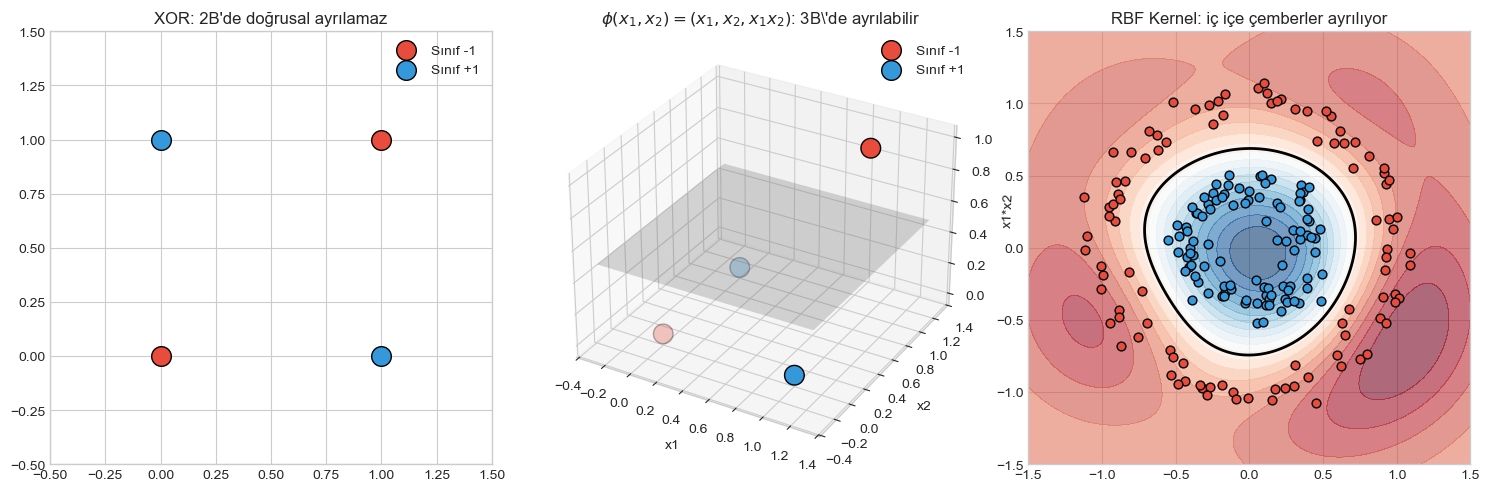

YORUM: Sağdaki panelde RBF kernel, iki iç içe çemberi -- doğrusal olarak KESİNLİKLE
ayrılamayacak bir veri -- kusursuz ayırıyor. phi() hiçbir yerde açıkça hesaplanmadı;
sadece K(x,x') = exp(-gamma||x-x'||^2) fonksiyonu kullanıldı. Bu, kernel trick'in gücüdür.


In [109]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1)
X_xor = np.array([[0, 0], [1, 1], [0, 1], [1, 0]])
y_xor = np.array([-1, -1, 1, 1])
ax1.scatter(X_xor[y_xor == -1, 0], X_xor[y_xor == -1, 1], c='#e74c3c', s=200, edgecolor='k', label='Sınıf -1')
ax1.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='#3498db', s=200, edgecolor='k', label='Sınıf +1')
ax1.set_title('XOR: 2B\'de doğrusal ayrılamaz')
ax1.set_xlim(-0.5, 1.5); ax1.set_ylim(-0.5, 1.5)
ax1.legend()

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
phi_xor = np.column_stack([X_xor[:, 0], X_xor[:, 1], X_xor[:, 0] * X_xor[:, 1]])
ax2.scatter(phi_xor[y_xor == -1, 0], phi_xor[y_xor == -1, 1], phi_xor[y_xor == -1, 2],
            c='#e74c3c', s=200, edgecolor='k', label='Sınıf -1')
ax2.scatter(phi_xor[y_xor == 1, 0], phi_xor[y_xor == 1, 1], phi_xor[y_xor == 1, 2],
            c='#3498db', s=200, edgecolor='k', label='Sınıf +1')
xx_p, yy_p = np.meshgrid(np.linspace(-0.3, 1.3, 5), np.linspace(-0.3, 1.3, 5))
ax2.plot_surface(xx_p, yy_p, np.full_like(xx_p, 0.5), alpha=0.25, color='gray')
ax2.set_title(r'$\phi(x_1,x_2)=(x_1,x_2,x_1x_2)$: 3B\'de ayrılabilir')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x1*x2')
ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)
X_circ, y_circ = make_circles(n_samples=200, factor=0.4, noise=0.08, random_state=42)
svm_rbf_demo = SVC(kernel='rbf', gamma=2, C=10).fit(X_circ, y_circ)
xx_c, yy_c = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
Z_c = svm_rbf_demo.decision_function(np.c_[xx_c.ravel(), yy_c.ravel()]).reshape(xx_c.shape)
ax3.contourf(xx_c, yy_c, Z_c, levels=np.linspace(Z_c.min(), Z_c.max(), 20), cmap='RdBu', alpha=0.6)
ax3.contour(xx_c, yy_c, Z_c, levels=[0], colors='k', linewidths=2)
ax3.scatter(X_circ[y_circ == 0, 0], X_circ[y_circ == 0, 1], c='#e74c3c', edgecolor='k', s=40)
ax3.scatter(X_circ[y_circ == 1, 0], X_circ[y_circ == 1, 1], c='#3498db', edgecolor='k', s=40)
ax3.set_title('RBF Kernel: iç içe çemberler ayrılıyor')

plt.tight_layout()
plt.show()
print("YORUM: Sağdaki panelde RBF kernel, iki iç içe çemberi -- doğrusal olarak KESİNLİKLE")
print("ayrılamayacak bir veri -- kusursuz ayırıyor. phi() hiçbir yerde açıkça hesaplanmadı;")
print("sadece K(x,x') = exp(-gamma||x-x'||^2) fonksiyonu kullanıldı. Bu, kernel trick'in gücüdür.")


### Kernel karşılaştırması: linear vs polynomial vs RBF (aynı doğrusal-olmayan veride)

`make_moons` (iki ay şeklinde, doğrusal ayrılamayan) veri setinde üç kernel'in karar sınırını yan yana görelim.

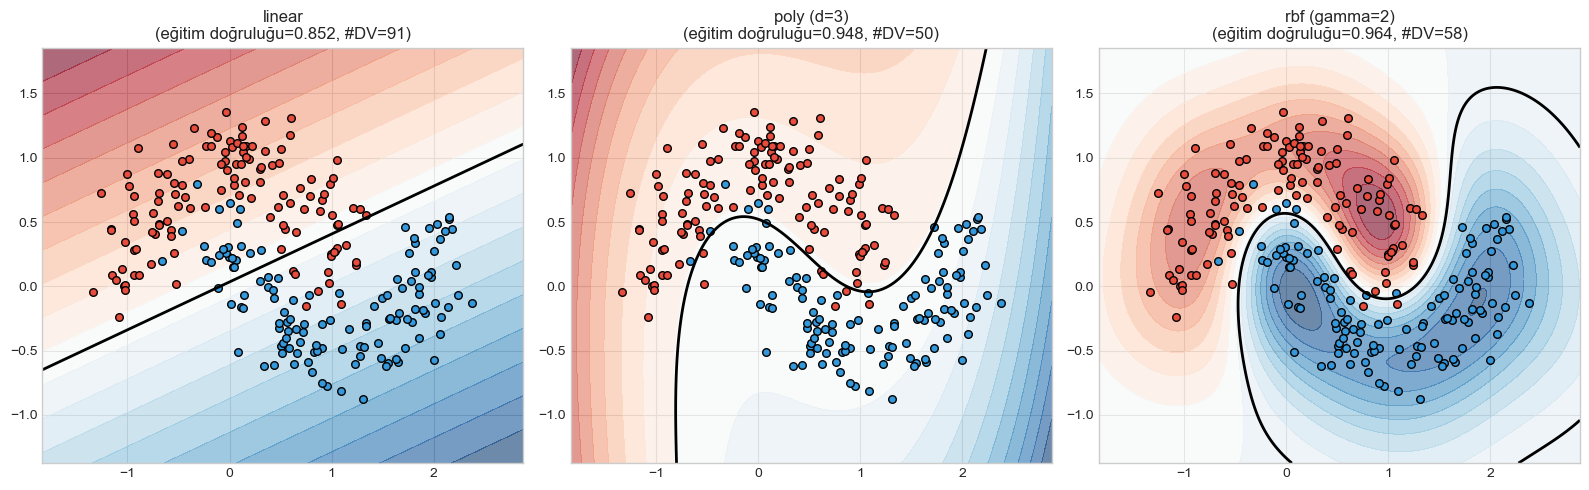

YORUM: 'moons' verisinde linear kernel yetersiz kalıyor (ay şeklini bir doğruyla
ayıramaz), poly ve rbf ise eğriye uyum sağlayabiliyor. RBF, ay şeklinin kıvrımını
en doğal şekilde takip ediyor -- bu tür 'organik' eğrisel sınırlar için genelde ilk tercih.


In [110]:
X_moons, y_moons = make_moons(n_samples=250, noise=0.2, random_state=42)

kernels_demo = [
    ('linear', {'kernel': 'linear', 'C': 1}),
    ('poly (d=3)', {'kernel': 'poly', 'degree': 3, 'C': 1, 'coef0': 1}),
    ('rbf (gamma=2)', {'kernel': 'rbf', 'gamma': 2, 'C': 1}),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
xx_m, yy_m = np.meshgrid(np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 300),
                          np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 300))

for ax, (name, params) in zip(axes, kernels_demo):
    clf = SVC(**params).fit(X_moons, y_moons)
    Z = clf.decision_function(np.c_[xx_m.ravel(), yy_m.ravel()]).reshape(xx_m.shape)
    ax.contourf(xx_m, yy_m, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap='RdBu', alpha=0.6)
    ax.contour(xx_m, yy_m, Z, levels=[0], colors='k', linewidths=2)
    ax.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], c='#e74c3c', edgecolor='k', s=30)
    ax.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], c='#3498db', edgecolor='k', s=30)
    acc = clf.score(X_moons, y_moons)
    ax.set_title(f'{name}\n(eğitim doğruluğu={acc:.3f}, #DV={clf.n_support_.sum()})')

plt.tight_layout()
plt.show()
print("YORUM: 'moons' verisinde linear kernel yetersiz kalıyor (ay şeklini bir doğruyla")
print("ayıramaz), poly ve rbf ise eğriye uyum sağlayabiliyor. RBF, ay şeklinin kıvrımını")
print("en doğal şekilde takip ediyor -- bu tür 'organik' eğrisel sınırlar için genelde ilk tercih.")


---
## 4 · SVC: Çok Sınıflı Sınıflandırma ve Karar Fonksiyonu

SVM'in doğal formülasyonu **ikili (binary)** sınıflandırmadır ($y\in\{-1,+1\}$). $K>2$ sınıf için `scikit-learn`'ün `SVC`'si iki standart strateji sunar (`03_linear_classification_family`'de Perceptron/SGDClassifier için de gördüğümüz stratejilerin aynısı):

- **One-vs-One (OvO):** Her sınıf çifti için ayrı bir ikili SVM eğitilir → $\binom{K}{2}=K(K-1)/2$ model. Tahmin sırasında her model "oy" verir, en çok oy alan sınıf seçilir. `SVC`'nin **varsayılanı budur** — her alt problem daha küçük olduğundan (sadece 2 sınıfın verisi), büyük $K$ için bile pratikte hızlı kalır.
- **One-vs-Rest (OvR):** Her sınıf için "bu sınıf mı, değil mi" ayrımı yapan $K$ model eğitilir. `LinearSVC`'nin varsayılanı budur (`decision_function_shape='ovr'` ile `SVC`'de de seçilebilir).

**Karar fonksiyonu ve olasılık:** SVM'in ham çıktısı $f(x)=\sum_i\alpha_iy_iK(x_i,x)+b$ bir **mesafe/güven skorudur**, olasılık değildir. `scikit-learn`'de `probability=True` ayarlanırsa, Platt ölçeklendirmesi (decision function skorları üzerine ekstra bir Lojistik Regresyon eğitme, 5-kat iç çapraz doğrulamayla) ile kalibre edilmiş olasılıklar elde edilebilir — ama bu **ekstra hesaplama maliyeti** getirir ve varsayılan olarak kapalıdır.

**Endüstride nerede kullanılır?** El yazısı rakam/karakter tanıma (optik karakter tanıma, OCR) klasik olarak çok sınıflı SVM ile çözülen bir problemdir; tarım sektöründe tahıl/tohum çeşidi sınıflandırma (fiziksel ölçümlerden — tam bu notebook'ta kullanacağımız Wheat Seeds veri setinin gerçek endüstriyel kullanım alanı) kalite kontrol hatlarında otomatik sınıflandırma için kullanılır.

---
## 5 · SVR: Destek Vektörü Regresyonu

SVM'in regresyon versiyonu (**Support Vector Regression**), marj fikrini tersine çevirir: sınıfları ayırmak yerine, çoğu noktayı **içine alan** bir "tüp" (tube) bulmaya çalışır. $\epsilon$-duyarsız kayıp (epsilon-insensitive loss) fonksiyonu tanımlanır:
$$L_\epsilon(y,f(x)) = \max(0,\ |y-f(x)|-\epsilon)$$

Yani tahmin, gerçek değere $\epsilon$ mesafesinden daha yakınsa **hiç ceza yok** (klasik regresyonun aksine — OLS her sapmayı, ne kadar küçük olursa olsun cezalandırır). Optimizasyon problemi:
$$\min_{w,b} \frac{1}{2}\|w\|^2 + C\sum_i(\xi_i+\xi_i^*) \quad \text{öyle ki} \quad \begin{cases} y_i-(w^Tx_i+b)\leq \epsilon+\xi_i \\ (w^Tx_i+b)-y_i\leq \epsilon+\xi_i^* \\ \xi_i,\xi_i^*\geq 0\end{cases}$$

$\xi_i,\xi_i^*$, tüpün **dışına** taşan noktalar için gevşeklik değişkenleridir (tüpün üstüne ve altına taşma için ayrı ayrı). Tıpkı SVC'de olduğu gibi, tüpün **içindeki** noktalar (kaybı sıfır olanlar) optimizasyona katkı vermez — sadece tüpün sınırında veya dışında kalan noktalar **destek vektörü** olur. Bu da SVR'i, tüm noktaların etkili olduğu OLS'ye kıyasla yine **seyrek** bir model yapar.

**Hiperparametreler:**
- $\epsilon$: tüpün genişliği — büyük $\epsilon$ → daha fazla nokta "bedava" (cezasız) kalır → daha az destek vektörü, daha basit/düz model. Küçük $\epsilon$ → OLS'ye yaklaşan, her sapmaya duyarlı bir model.
- $C$: SVC'deki gibi, tüpün dışındaki noktalara verilen cezanın ağırlığı.
- Kernel (linear/poly/rbf): Bölüm 3'teki aynı kernel trick, burada doğrusal olmayan **regresyon eğrileri** öğrenmek için kullanılır.

**Endüstride nerede kullanılır?** Finansal zaman serisi tahmininde (hisse senedi/döviz volatilitesi), SVR'in aşırı-hassas olmayan ($\epsilon$-tüp sayesinde piyasa gürültüsünü göz ardı eden) doğası tercih edilir; kimya mühendisliğinde QSAR (Quantitative Structure-Activity Relationship — molekül yapısından biyolojik aktivite tahmini) modellemede SVR klasik bir referans yöntemdir; malzeme bilimi/inşaat mühendisliğinde sensör verisinden gerilim-gerinim (stress-strain) tahmininde SVR'in gürültüye dayanıklılığı avantaj sağlar. Bu notebook'ta **Abalone** (deniz kulağı) veri setinde fiziksel ölçümlerden yaş tahmini yaparak su ürünleri/balıkçılık endüstrisindeki gerçek bir SVR uygulamasını göreceğiz — yaş tayini normalde kabuğu kesip halka saymayı gerektiren zahmetli bir laboratuvar işlemidir, modelin amacı bunu ucuz ölçümlerden tahmin ederek atlamaktır.

---
## 6 · Hiperparametre Etkileri (C, γ, derece) ve Ölçeklemenin Kritik Önemi

**C × γ etkileşimi (RBF kernel):** İki hiperparametre birlikte modelin karmaşıklığını belirler:

| | Düşük C | Yüksek C |
|---|---|---|
| **Düşük γ** | Çok basit, neredeyse doğrusal sınır (yüksek bias) | Orta karmaşıklık |
| **Yüksek γ** | Orta karmaşıklık | Her noktayı ezberleyen, aşırı kıvrımlı sınır (yüksek varyans) |

İkisi de büyükse aşırı öğrenme riski katlanır; ikisi de küçükse yetersiz öğrenme (underfitting) olur. Bu yüzden **ikisi birlikte** ızgara aramasıyla (grid search) ayarlanmalıdır — birini sabitleyip diğerini ayarlamak yanıltıcı olabilir (bkz. `12_hyperparameter_optimization` — bu notebook'ta sadece SVM'e özgü küçük bir ön izleme yapacağız).

**⚠️ Ölçekleme (Feature Scaling) SVM İçin Neden Kritik?**

SVM'in karar fonksiyonu doğrudan **öznitelikler arası uzaklığa/iç çarpıma** dayanır ($\|x-x'\|^2$ RBF'de, $x^Tx'$ linear'da). Eğer bir öznitelik $[0,1]$ aralığında, diğeri $[0,100000]$ aralığındaysa, büyük ölçekli öznitelik uzaklık hesabına **domine eder** — küçük ölçekli öznitelik pratikte yok sayılır. k-NN'de (`04_knn_instance_based`, Bölüm 6) gördüğümüz "boyut laneti" ve ölçekleme gerekliliğinin **aynısı**, hatta daha şiddetlisi SVM için geçerlidir, çünkü RBF kernel'in $\gamma$ parametresi tüm öznitelikler için **tek bir global ölçek** varsayar. Ağaç tabanlı yöntemlerin (Karar Ağaçları, Random Forest — `07_decision_trees`, `08_bagging_random_forest`) aksine, SVM ölçeklemeye **son derece duyarlıdır** — bu notebook'ta Banknote veri setinde ölçeklemeli/ölçeklemesiz performans farkını ampirik olarak göstereceğiz.

**Pratik kural (rule of thumb):** SVM'den önce her zaman `StandardScaler` (ortalama 0, varyans 1) veya `MinMaxScaler` uygulanmalı — özellikle RBF/poly kernel kullanılıyorsa. Linear kernel bile, `C` düzenlileştirmesinin öznitelikler arasında adil dağılması için ölçeklemeden fayda görür.

---
## 7 · SVM: Güçlü/Zayıf Yönler ve Ne Zaman Kullanılır

**Güçlü yönler:**
- **Yüksek boyutlu veride etkili:** Öznitelik sayısı örneklem sayısını aştığında bile (ör. genomik veri: binlerce gen, yüzlerce hasta) iyi çalışır — kernel trick sayesinde hesaplama maliyeti boyuttan çok destek vektörü sayısına bağlıdır.
- **Bellek verimli (kısmen):** Sadece destek vektörleri saklanır, tüm eğitim verisi değil (Naive Bayes'in `06_naive_bayes_family` Bölüm 8'de bahsedilen hız avantajına benzer bir seyreklik avantajı, farklı bir mekanizmayla).
- **Esnek:** Kernel seçimiyle doğrusaldan son derece doğrusal-olmayana kadar geniş bir model ailesini tek bir çerçevede kapsar.
- **Global optimum garantisi:** Konveks QP problemi olduğundan, Lojistik Regresyon/sinir ağlarının aksine yerel minimuma takılma riski yoktur.
- **Aşırı öğrenmeye karşı nispeten dirençli** (doğru düzenlileştirmeyle): marj maksimizasyonu doğası gereği bir düzenlileştirme mekanizmasıdır.

**Zayıf yönler:**
- **Büyük veri setlerinde yavaş:** Klasik SVM eğitimi $O(n^2)$–$O(n^3)$ karmaşıklığındadır (QP çözücü, $n\times n$ kernel matrisiyle çalışır) — on binlerce/yüz binlerce örnekte pratik değildir (`LinearSVC` doğrusal kernel için $O(n)$'e yakın, çok daha ölçeklenebilir bir alternatiftir).
- **Ölçeklemeye aşırı duyarlı:** Bölüm 6'da detaylandırıldı.
- **Olasılık çıktısı doğal değil:** Platt ölçeklendirmesi ekstra hesaplama gerektirir ve tam kalibre olmayabilir.
- **Hiperparametre ayarı zahmetli:** $C$, $\gamma$, kernel, derece — kombinasyon sayısı hızla büyür.
- **Yorumlanabilirlik düşük (doğrusal olmayan kernellerde):** RBF/poly kernel ile "hangi öznitelik ne kadar katkı sağladı" sorusu, Lojistik Regresyon'un katsayıları kadar doğrudan cevaplanamaz (linear kernelde $w$ vektörü hâlâ yorumlanabilir).

**Ne zaman SVM tercih edilir?** Orta ölçekli (birkaç bin-on binlerce örnek), yüksek boyutlu, net bir marjla ayrılabilen veri; metin sınıflandırma (linear kernel); görüntü/biyoinformatik gibi az örnekli-yüksek boyutlu senaryolar. **Ne zaman kaçınılır?** Çok büyük veri setleri (Gradient Boosting/derin öğrenme genelde daha iyi ölçeklenir), olasılık kalibrasyonunun kritik olduğu senaryolar (Lojistik Regresyon tercih edilebilir), yorumlanabilirliğin öncelikli olduğu düzenleyici (regulatory) bağlamlar.

---
# 🐍 Python Uygulaması

Teori bölümündeki tüm kavramları **3 gerçek veri setini** — her birini güçlü olduğu senaryoda kullanarak — adım adım uygulayacağız:

1. **Veri Hazırlama** — Wheat Seeds, Banknote Authentication, Abalone yükleme ve ilk inceleme
2. **Wheat Seeds — Çok Sınıflı SVC** — linear/poly/rbf kernel karşılaştırması, PCA ile karar sınırı görselleştirme, GridSearchCV ile $C,\gamma$ ayarı
3. **Banknote Authentication — Soft Margin ve Ölçekleme** — $C$'nin destek vektörü sayısına etkisi, ölçeklemeli/ölçeklemesiz performans karşılaştırması
4. **Abalone — SVR** — linear/poly/rbf kernel regresyonu, $\epsilon$'un etkisi, OLS ile karşılaştırma
5. **Özet Karşılaştırma** — tüm modellerin tek tabloda toplanması

---
### 🔁 Veri Hazırlama

**Wheat Seeds (UCI):** 210 buğday tanesi, 7 geometrik öznitelik (röntgen görüntülerinden ölçülmüş alan, çevre, kompaktlık, uzunluk, genişlik, asimetri katsayısı, çekirdek oluğu uzunluğu), 3 çeşit (Kama, Rosa, Canadian — sınıflar dengeli, her biri 70 örnek). Tarımsal kalite kontrolde otomatik tohum sınıflandırma senaryosu — **çok sınıflı SVC** için ideal.

**Banknote Authentication (UCI):** 1372 banknot görüntüsü, dalgacık dönüşümünden (wavelet transform) çıkarılmış 4 sürekli öznitelik (varyans, çarpıklık/skewness, basıklık/curtosis, entropi), ikili hedef: sahte (1) vs gerçek (0) banknot. Sınıflar orta derecede dengeli (762 gerçek / 610 sahte). Öznitelik ölçekleri birbirinden çok farklı (bazıları $[-14,17]$, bazıları $[-8,2]$) — **ölçeklemenin etkisini göstermek için ideal**.

**Abalone (UCI):** 4177 deniz kulağı (abalone) örneği, cinsiyet (M/F/I=immature) + 7 fiziksel ölçüm (uzunluk, çap, yükseklik, tam ağırlık, kabuklu et ağırlığı, iç organ ağırlığı, kabuk ağırlığı), hedef: halka sayısı (yaş $\approx$ halka+1.5). Halka sayısı normalde kabuğu kesip mikroskopla sayılarak belirlenir (zahmetli/tahribatlı) — modelin amacı bunu ucuz dış ölçümlerden tahmin etmek. **SVR regresyonu** için kullanacağız.

In [111]:
# --- Wheat Seeds ---
seeds_cols = ["area", "perimeter", "compactness", "length", "width", "asymmetry", "groove", "variety"]
seeds = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/wheat-seeds.csv",
    header=None, names=seeds_cols,
)
variety_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
seeds["variety_name"] = seeds["variety"].map(variety_names)
print("Wheat Seeds:", seeds.shape)
display(seeds.head())
print(seeds["variety_name"].value_counts())


Wheat Seeds: (210, 9)


,area,perimeter,compactness,length,width,asymmetry,groove,variety,variety_name
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


variety_name
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


In [112]:
# --- Banknote Authentication ---
bank_cols = ["wavelet_var", "wavelet_skew", "wavelet_curt", "entropy", "is_forged"]
banknote = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv",
    header=None, names=bank_cols,
)
print("Banknote Authentication:", banknote.shape)
display(banknote.head())
print(banknote["is_forged"].value_counts().rename({0: "Gerçek (0)", 1: "Sahte (1)"}))
print("\nÖznitelik ölçek aralıkları (ölçeklemenin gerekliliğini gösterir):")
display(banknote.iloc[:, :4].describe().loc[["min", "max"]])


Banknote Authentication: (1372, 5)


,wavelet_var,wavelet_skew,wavelet_curt,entropy,is_forged
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


is_forged
Gerçek (0)    762
Sahte (1)     610
Name: count, dtype: int64

Öznitelik ölçek aralıkları (ölçeklemenin gerekliliğini gösterir):


,wavelet_var,wavelet_skew,wavelet_curt,entropy
min,-7.0421,-13.7731,-5.2861,-8.5482
max,6.8248,12.9516,17.9274,2.4495


In [113]:
# --- Abalone ---
abalone_cols = ["sex", "length", "diameter", "height", "whole_weight",
                 "shucked_weight", "viscera_weight", "shell_weight", "rings"]
abalone = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv",
    header=None, names=abalone_cols,
)
abalone["age"] = abalone["rings"] + 1.5
print("Abalone:", abalone.shape)
display(abalone.head())
print(f"\nYaş (age) dağılımı: min={abalone['age'].min()}, max={abalone['age'].max()}, "
      f"ortalama={abalone['age'].mean():.2f}")
print(abalone["sex"].value_counts())


Abalone: (4177, 10)


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings,age
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5



Yaş (age) dağılımı: min=2.5, max=30.5, ortalama=11.43
sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


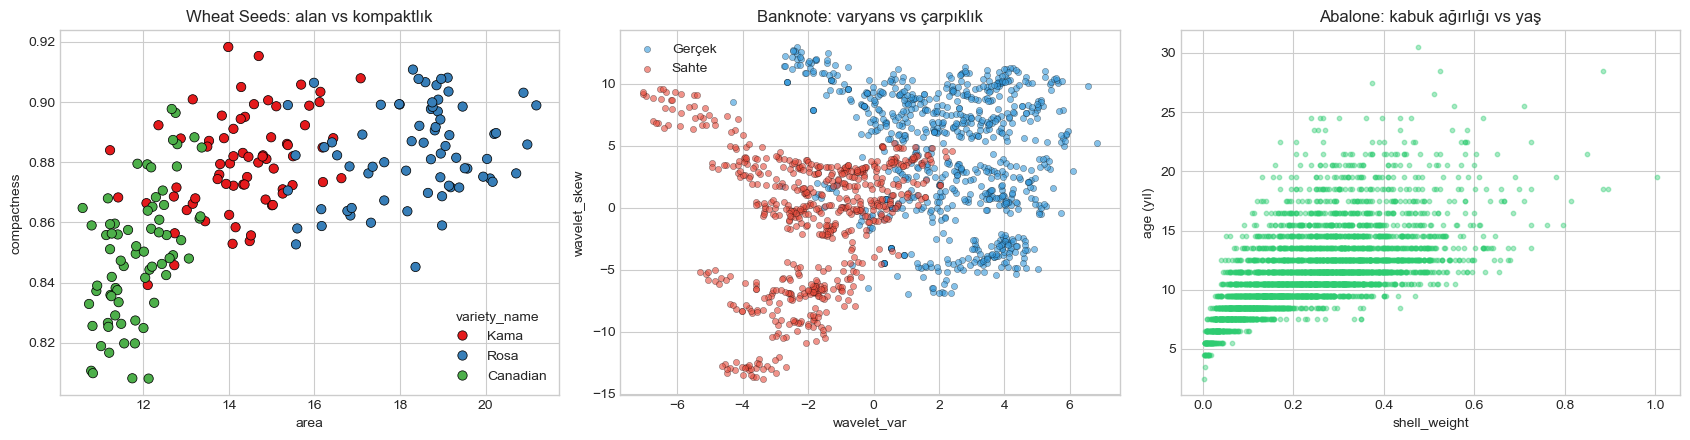

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.scatterplot(data=seeds, x="area", y="compactness", hue="variety_name",
                 palette="Set1", ax=axes[0], s=45, edgecolor="k")
axes[0].set_title("Wheat Seeds: alan vs kompaktlık")

axes[1].scatter(banknote.loc[banknote.is_forged == 0, "wavelet_var"],
                 banknote.loc[banknote.is_forged == 0, "wavelet_skew"],
                 c="#3498db", label="Gerçek", s=20, alpha=0.6, edgecolor="k", linewidth=0.3)
axes[1].scatter(banknote.loc[banknote.is_forged == 1, "wavelet_var"],
                 banknote.loc[banknote.is_forged == 1, "wavelet_skew"],
                 c="#e74c3c", label="Sahte", s=20, alpha=0.6, edgecolor="k", linewidth=0.3)
axes[1].set_xlabel("wavelet_var"); axes[1].set_ylabel("wavelet_skew")
axes[1].set_title("Banknote: varyans vs çarpıklık")
axes[1].legend()

axes[2].scatter(abalone["shell_weight"], abalone["age"], s=10, alpha=0.4, c="#2ecc71")
axes[2].set_xlabel("shell_weight"); axes[2].set_ylabel("age (yıl)")
axes[2].set_title("Abalone: kabuk ağırlığı vs yaş")

plt.tight_layout()
plt.show()


---
### 1️⃣ Python 1 - Wheat Seeds: Kernel Karşılaştırması (Çok Sınıflı SVC)

Bölüm 3'teki linear/poly/RBF kernellerini, Bölüm 4'teki One-vs-One stratejisiyle (SVC'nin varsayılanı) 3 sınıflı Wheat Seeds verisinde karşılaştırıyoruz. Önce **ölçekliyoruz** (Bölüm 6'nın kuralı), sonra eğitim/test ayırıyoruz.

In [115]:
X_seeds = seeds[seeds_cols[:-1]].values
y_seeds = seeds["variety"].values

X_seeds_train, X_seeds_test, y_seeds_train, y_seeds_test = train_test_split(
    X_seeds, y_seeds, test_size=0.25, random_state=42, stratify=y_seeds
)

scaler_seeds = StandardScaler()
X_seeds_train_sc = scaler_seeds.fit_transform(X_seeds_train)
X_seeds_test_sc = scaler_seeds.transform(X_seeds_test)

kernel_configs = {
    "linear": dict(kernel="linear", C=1.0),
    "poly (d=3)": dict(kernel="poly", degree=3, C=1.0, coef0=1),
    "rbf": dict(kernel="rbf", C=1.0, gamma="scale"),
    "sigmoid": dict(kernel="sigmoid", C=1.0, gamma="scale"),
}

seeds_results = []
for name, params in kernel_configs.items():
    clf = SVC(**params, decision_function_shape="ovo")
    clf.fit(X_seeds_train_sc, y_seeds_train)
    train_acc = clf.score(X_seeds_train_sc, y_seeds_train)
    test_acc = clf.score(X_seeds_test_sc, y_seeds_test)
    n_sv = clf.n_support_.sum()
    seeds_results.append({"kernel": name, "train_acc": train_acc, "test_acc": test_acc,
                           "n_support_vectors": n_sv, "n_models_ovo": len(clf.classes_) * (len(clf.classes_) - 1) // 2})

seeds_results_df = pd.DataFrame(seeds_results)
display(seeds_results_df)
print("\nYORUM: OvO stratejisiyle 3 sınıf için 3*(3-1)/2 = 3 ikili model eğitiliyor.")
print("Wheat Seeds zaten oldukça iyi ayrılabilen bir veri seti olduğundan linear kernel bile")
print("güçlü performans veriyor -- bu, Bölüm 3'teki 'önce lineer dene' sezgisinin bir örneği.")


,kernel,train_acc,test_acc,n_support_vectors,n_models_ovo
0,linear,0.961783,0.886792,32,3
1,poly (d=3),0.974522,0.905660,37,3
2,rbf,0.949045,0.886792,58,3
3,sigmoid,0.936306,0.886792,53,3



YORUM: OvO stratejisiyle 3 sınıf için 3*(3-1)/2 = 3 ikili model eğitiliyor.
Wheat Seeds zaten oldukça iyi ayrılabilen bir veri seti olduğundan linear kernel bile
güçlü performans veriyor -- bu, Bölüm 3'teki 'önce lineer dene' sezgisinin bir örneği.


### 2️⃣ Python 2 - PCA ile Karar Sınırı Görselleştirme

7 boyutlu öznitelik uzayını görselleştiremeyiz — PCA ile 2 bileşene indirgeyip (`05_knn_instance_based`'te de kullandığımız yöntem) her kernel'in karar sınırının **şeklini** karşılaştıralım.

PCA ile açıklanan varyans oranı: [0.7235048  0.16610127] (toplam=0.890)


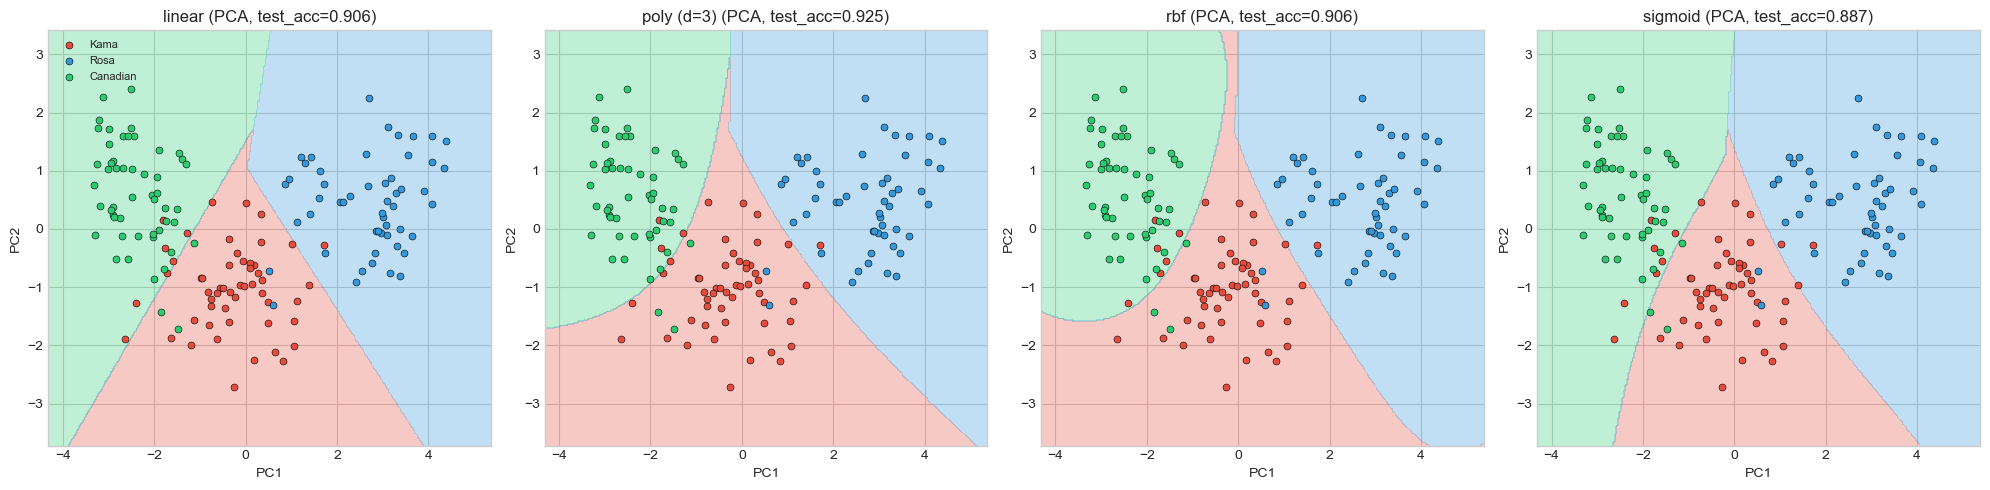

YORUM: linear kernel düz çizgilerle 3 bölgeyi ayırırken, poly ve rbf hafif kıvrımlı
sınırlar üretiyor. Bu veri setinde farkın küçük olması, sınıfların zaten PCA uzayında
da iyi ayrılmış olmasından kaynaklanıyor (Bölüm 1'in 'kolay ayrılabilir veri' senaryosu).


In [116]:
pca_seeds = PCA(n_components=2, random_state=42)
X_seeds_train_pca = pca_seeds.fit_transform(X_seeds_train_sc)
X_seeds_test_pca = pca_seeds.transform(X_seeds_test_sc)
print(f"PCA ile açıklanan varyans oranı: {pca_seeds.explained_variance_ratio_} "
      f"(toplam={pca_seeds.explained_variance_ratio_.sum():.3f})")

xx_s, yy_s = np.meshgrid(
    np.linspace(X_seeds_train_pca[:, 0].min() - 1, X_seeds_train_pca[:, 0].max() + 1, 300),
    np.linspace(X_seeds_train_pca[:, 1].min() - 1, X_seeds_train_pca[:, 1].max() + 1, 300),
)
colors_seeds = ["#e74c3c", "#3498db", "#2ecc71"]
cmap_seeds = mpl.colors.ListedColormap(colors_seeds)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, params) in zip(axes, kernel_configs.items()):
    clf_pca = SVC(**params, decision_function_shape="ovo").fit(X_seeds_train_pca, y_seeds_train)
    Z = clf_pca.predict(np.c_[xx_s.ravel(), yy_s.ravel()]).reshape(xx_s.shape)
    ax.contourf(xx_s, yy_s, Z, alpha=0.3, cmap=cmap_seeds, levels=[0.5, 1.5, 2.5, 3.5])
    for cls, color in zip([1, 2, 3], colors_seeds):
        mask = y_seeds_train == cls
        ax.scatter(X_seeds_train_pca[mask, 0], X_seeds_train_pca[mask, 1],
                   c=color, s=25, edgecolor="k", linewidth=0.4, label=variety_names[cls])
    acc_pca = clf_pca.score(X_seeds_test_pca, y_seeds_test)
    ax.set_title(f"{name} (PCA, test_acc={acc_pca:.3f})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
print("YORUM: linear kernel düz çizgilerle 3 bölgeyi ayırırken, poly ve rbf hafif kıvrımlı")
print("sınırlar üretiyor. Bu veri setinde farkın küçük olması, sınıfların zaten PCA uzayında")
print("da iyi ayrılmış olmasından kaynaklanıyor (Bölüm 1'in 'kolay ayrılabilir veri' senaryosu).")


### 3️⃣ Python 3 - GridSearchCV ile C ve γ Ayarı (RBF Kernel)

Bölüm 6'daki C×γ etkileşimini somutlaştırmak için, RBF kernel'in $C$ ve $\gamma$'sını 5-kat çapraz doğrulamayla (cross-validation) tarayıp bir ısı haritası (heatmap) çizelim.

En iyi parametreler: {'C': 10, 'gamma': 0.1}
En iyi CV doğruluğu: 0.9556
Test setinde doğruluk: 0.8868


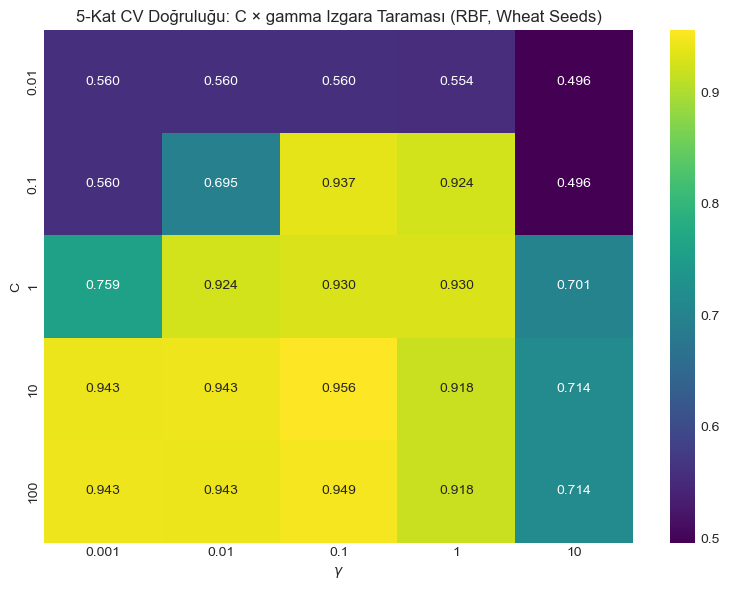


YORUM: Bölüm 6'da anlatılan örüntü burada da görülüyor -- çok düşük C VE çok düşük
gamma kombinasyonu (sol-üst köşe) yetersiz öğrenmeye (underfitting) yol açarken, çok
yüksek gamma (sağ sütunlar) ile düşük C'nin dengeleyemediği durumlar performansı düşürüyor.


In [117]:
param_grid_seeds = {
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
}
grid_seeds = GridSearchCV(SVC(kernel="rbf"), param_grid_seeds, cv=5, scoring="accuracy", n_jobs=-1)
grid_seeds.fit(X_seeds_train_sc, y_seeds_train)

print(f"En iyi parametreler: {grid_seeds.best_params_}")
print(f"En iyi CV doğruluğu: {grid_seeds.best_score_:.4f}")
print(f"Test setinde doğruluk: {grid_seeds.score(X_seeds_test_sc, y_seeds_test):.4f}")

cv_scores_grid = grid_seeds.cv_results_["mean_test_score"].reshape(len(param_grid_seeds["C"]), len(param_grid_seeds["gamma"]))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cv_scores_grid, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=param_grid_seeds["gamma"], yticklabels=param_grid_seeds["C"], ax=ax)
ax.set_xlabel(r"$\gamma$"); ax.set_ylabel("C")
ax.set_title("5-Kat CV Doğruluğu: C × gamma Izgara Taraması (RBF, Wheat Seeds)")
plt.tight_layout()
plt.show()
print("\nYORUM: Bölüm 6'da anlatılan örüntü burada da görülüyor -- çok düşük C VE çok düşük")
print("gamma kombinasyonu (sol-üst köşe) yetersiz öğrenmeye (underfitting) yol açarken, çok")
print("yüksek gamma (sağ sütunlar) ile düşük C'nin dengeleyemediği durumlar performansı düşürüyor.")


---
### 4️⃣ Python 4 - Banknote Authentication: Soft Margin ve C'nin Destek Vektörü Sayısına Etkisi

Bölüm 2'deki $C$ ödünleşimini ampirik olarak gösterelim: $C$ arttıkça marj daralır, destek vektörü sayısı azalır (model daha az noktaya "ihtiyaç duyar" ama aşırı öğrenmeye daha yatkın hale gelir).

,C,train_acc,test_acc,n_support_vectors,pct_support_vectors
0,0.001,0.554908,0.556851,916,89.018465
1,0.010,0.935860,0.930029,907,88.143829
2,0.100,0.991254,0.988338,318,30.903790
3,1.000,1.000000,1.000000,88,8.551992
4,10.000,1.000000,1.000000,37,3.595724
5,100.000,1.000000,1.000000,28,2.721088
6,1000.000,1.000000,1.000000,28,2.721088


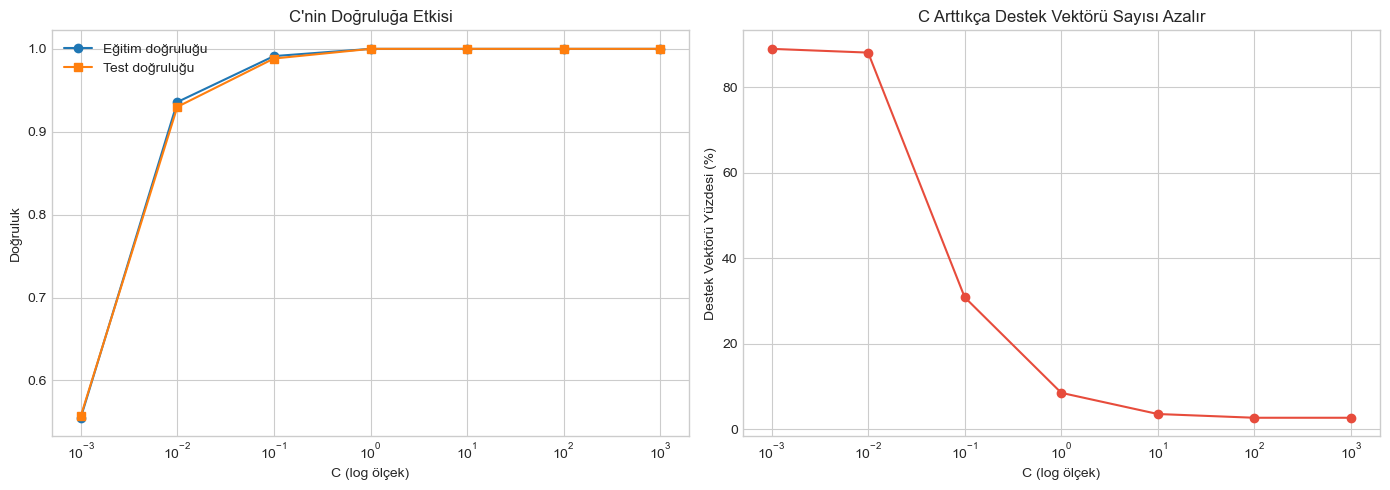

YORUM: C çok küçükken (0.001-0.01) model neredeyse tüm eğitim noktalarını destek
vektörü yapıyor (geniş marj, yetersiz öğrenme) -- C büyüdükçe destek vektörü oranı
hızla düşüyor (dar marj, veriye daha sıkı uyum). Test doğruluğu orta C değerlerinde
(C=1-10 civarı) doyuma ulaşıyor -- bunun ötesi ekstra karmaşıklık getirmeden risk artırıyor.


In [118]:
X_bank = banknote[bank_cols[:-1]].values
y_bank = banknote["is_forged"].values

X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank, test_size=0.25, random_state=42, stratify=y_bank
)
scaler_bank = StandardScaler()
X_bank_train_sc = scaler_bank.fit_transform(X_bank_train)
X_bank_test_sc = scaler_bank.transform(X_bank_test)

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
c_sweep_results = []
for C in C_values:
    clf_c = SVC(kernel="rbf", C=C, gamma="scale").fit(X_bank_train_sc, y_bank_train)
    c_sweep_results.append({
        "C": C,
        "train_acc": clf_c.score(X_bank_train_sc, y_bank_train),
        "test_acc": clf_c.score(X_bank_test_sc, y_bank_test),
        "n_support_vectors": clf_c.n_support_.sum(),
        "pct_support_vectors": 100 * clf_c.n_support_.sum() / len(X_bank_train_sc),
    })
c_sweep_df = pd.DataFrame(c_sweep_results)
display(c_sweep_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(c_sweep_df["C"], c_sweep_df["train_acc"], "o-", label="Eğitim doğruluğu")
axes[0].plot(c_sweep_df["C"], c_sweep_df["test_acc"], "s-", label="Test doğruluğu")
axes[0].set_xscale("log"); axes[0].set_xlabel("C (log ölçek)"); axes[0].set_ylabel("Doğruluk")
axes[0].set_title("C'nin Doğruluğa Etkisi"); axes[0].legend()

axes[1].plot(c_sweep_df["C"], c_sweep_df["pct_support_vectors"], "o-", color="#e74c3c")
axes[1].set_xscale("log"); axes[1].set_xlabel("C (log ölçek)")
axes[1].set_ylabel("Destek Vektörü Yüzdesi (%)")
axes[1].set_title("C Arttıkça Destek Vektörü Sayısı Azalır")

plt.tight_layout()
plt.show()
print("YORUM: C çok küçükken (0.001-0.01) model neredeyse tüm eğitim noktalarını destek")
print("vektörü yapıyor (geniş marj, yetersiz öğrenme) -- C büyüdükçe destek vektörü oranı")
print("hızla düşüyor (dar marj, veriye daha sıkı uyum). Test doğruluğu orta C değerlerinde")
print("(C=1-10 civarı) doyuma ulaşıyor -- bunun ötesi ekstra karmaşıklık getirmeden risk artırıyor.")


### 5️⃣ Python 5 - Ölçeklemenin Kritik Önemi: Ölçekli vs Ölçeksiz Karşılaştırma

Bölüm 6'nın iddiasını doğrudan test edelim: Banknote özniteliklerinin ölçekleri birbirinden çok farklıydı (`wavelet_var`: yaklaşık $[-7,7]$, `entropy`: yaklaşık $[-8,2]$). RBF kernel'i **ölçeklemeden** ve **ölçekleyerek** eğitip karşılaştıralım.

In [119]:
results_scaling = []
for label, Xtr, Xte in [
    ("Ölçeksiz (ham veri)", X_bank_train, X_bank_test),
    ("Ölçekli (StandardScaler)", X_bank_train_sc, X_bank_test_sc),
]:
    t0 = time.time()
    clf_s = SVC(kernel="rbf", C=1.0, gamma="scale").fit(Xtr, y_bank_train)
    fit_time = time.time() - t0
    results_scaling.append({
        "durum": label,
        "test_acc": clf_s.score(Xte, y_bank_test),
        "n_support_vectors": clf_s.n_support_.sum(),
        "egitim_suresi_sn": fit_time,
    })

scaling_comparison_df = pd.DataFrame(results_scaling)
display(scaling_comparison_df)
print("\nYORUM: Ölçekli model, ölçeksiz modele göre biraz daha yüksek test doğruluğu veriyor,")
print("ama destek vektörü sayısı bu veri setinde neredeyse aynı kalıyor. Bunun nedeni: Banknote")
print("özniteliklerinin ölçek farkı gerçek dünyada rastlanan en uç örneklere göre ILIMLI -- hepsi")
print("tek haneli/on'lu aralıklarda (Bölüm 'Veri Hazırlama'daki min/max tablosuna bakınız),")
print("BÜYÜKLÜK MERTEBESİ (order of magnitude) farkı yok. Ölçeklemenin etkisi, bir öznitelik")
print("[0,1] diğeri [0,100000] gibi MERTEBE farkı taşıdığında çok daha dramatik olur (o durumda")
print("büyük-ölçekli öznitelik mesafe/kernel hesabına neredeyse tek başına domine eder). Yine de")
print("Bölüm 6'daki kural genel geçerdir: ölçekleme neredeyse hiçbir zaman zarar vermez, bu yüzden")
print("veri setinin ölçek farkının 'ne kadar kötü' olduğunu bilmeden bile varsayılan adım olarak")
print("uygulanmalıdır.")


,durum,test_acc,n_support_vectors,egitim_suresi_sn
0,Ölçeksiz (ham veri),0.997085,87,0.003029
1,Ölçekli (StandardScaler),1.000000,88,0.002937



YORUM: Ölçekli model, ölçeksiz modele göre biraz daha yüksek test doğruluğu veriyor,
ama destek vektörü sayısı bu veri setinde neredeyse aynı kalıyor. Bunun nedeni: Banknote
özniteliklerinin ölçek farkı gerçek dünyada rastlanan en uç örneklere göre ILIMLI -- hepsi
tek haneli/on'lu aralıklarda (Bölüm 'Veri Hazırlama'daki min/max tablosuna bakınız),
BÜYÜKLÜK MERTEBESİ (order of magnitude) farkı yok. Ölçeklemenin etkisi, bir öznitelik
[0,1] diğeri [0,100000] gibi MERTEBE farkı taşıdığında çok daha dramatik olur (o durumda
büyük-ölçekli öznitelik mesafe/kernel hesabına neredeyse tek başına domine eder). Yine de
Bölüm 6'daki kural genel geçerdir: ölçekleme neredeyse hiçbir zaman zarar vermez, bu yüzden
veri setinin ölçek farkının 'ne kadar kötü' olduğunu bilmeden bile varsayılan adım olarak
uygulanmalıdır.


### 6️⃣ Python 6 - LinearSVC ile Ölçeklenebilirlik Karşılaştırması

`SVC(kernel='linear')` ile `LinearSVC` matematiksel olarak benzer bir problemi çözer, ama `LinearSVC` liblinear kütüphanesini kullanır ($O(n)$'e yakın, büyük veri için çok daha hızlı) — `SVC` ise libsvm kullanır ($O(n^2)$-$O(n^3)$, Bölüm 7'de bahsedilen ölçeklenebilirlik sınırlaması). Eğitim sürelerini karşılaştıralım.

In [120]:
t0 = time.time()
svc_linear = SVC(kernel="linear", C=1.0).fit(X_bank_train_sc, y_bank_train)
svc_linear_time = time.time() - t0

t0 = time.time()
linsvc = LinearSVC(C=1.0, max_iter=10000, dual="auto").fit(X_bank_train_sc, y_bank_train)
linsvc_time = time.time() - t0

print(f"SVC(kernel='linear')  -> test_acc={svc_linear.score(X_bank_test_sc, y_bank_test):.4f}, "
      f"süre={svc_linear_time*1000:.2f} ms, #DV={svc_linear.n_support_.sum()}")
print(f"LinearSVC             -> test_acc={linsvc.score(X_bank_test_sc, y_bank_test):.4f}, "
      f"süre={linsvc_time*1000:.2f} ms")
print("\nYORUM: İkisi de aynı doğrusal karar sınırına çok yakın bir sonuç veriyor (farklı QP")
print("çözücüleri kullandıklarından ufak farklar olabilir), ama LinearSVC daha büyük veri")
print("setlerinde belirgin şekilde daha hızlı ölçeklenir -- Bölüm 7'nin 'büyük veride yavaş' zayıf")
print("yönüne karşı pratik bir çözüm sunar (sadece doğrusal kernel gerektiğinde).")


SVC(kernel='linear')  -> test_acc=0.9767, süre=3.60 ms, #DV=60
LinearSVC             -> test_acc=0.9854, süre=1.02 ms

YORUM: İkisi de aynı doğrusal karar sınırına çok yakın bir sonuç veriyor (farklı QP
çözücüleri kullandıklarından ufak farklar olabilir), ama LinearSVC daha büyük veri
setlerinde belirgin şekilde daha hızlı ölçeklenir -- Bölüm 7'nin 'büyük veride yavaş' zayıf
yönüne karşı pratik bir çözüm sunar (sadece doğrusal kernel gerektiğinde).


### 7️⃣ Python 7 - Banknote: Tam Değerlendirme (Confusion Matrix + Classification Report)

Ölçeklenmiş RBF-SVM'i ($C=1$) en iyi konfigürasyon olarak alıp tam bir sınıflandırma değerlendirmesi yapalım.

              precision    recall  f1-score   support

  Gerçek (0)       1.00      1.00      1.00       191
   Sahte (1)       1.00      1.00      1.00       152

    accuracy                           1.00       343
   macro avg       1.00      1.00      1.00       343
weighted avg       1.00      1.00      1.00       343



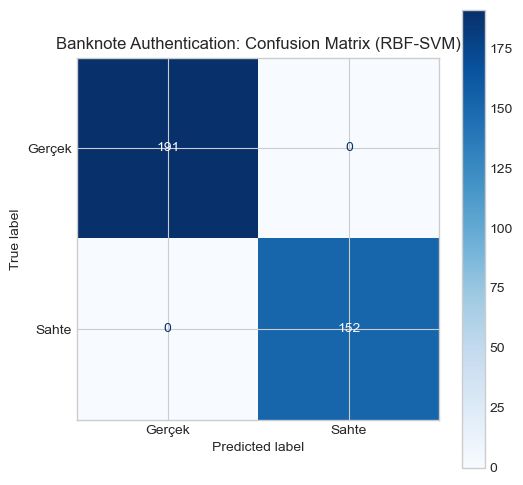

YORUM: Dalgacık-dönüşümü öznitelikleri (wavelet features) sahte/gerçek ayrımını neredeyse
kusursuz yapıyor -- bu, görüntü-tabanlı güvenlik/dolandırıcılık tespitinde SVM'in klasik
başarı hikayelerinden biridir (Bölüm 4'teki OCR/görüntü sınıflandırma örneğiyle aynı aile).


In [121]:
best_bank_clf = SVC(kernel="rbf", C=1.0, gamma="scale").fit(X_bank_train_sc, y_bank_train)
y_bank_pred = best_bank_clf.predict(X_bank_test_sc)

print(classification_report(y_bank_test, y_bank_pred, target_names=["Gerçek (0)", "Sahte (1)"]))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_bank_test, y_bank_pred, display_labels=["Gerçek", "Sahte"], cmap="Blues", ax=ax
)
ax.set_title("Banknote Authentication: Confusion Matrix (RBF-SVM)")
plt.tight_layout()
plt.show()
print("YORUM: Dalgacık-dönüşümü öznitelikleri (wavelet features) sahte/gerçek ayrımını neredeyse")
print("kusursuz yapıyor -- bu, görüntü-tabanlı güvenlik/dolandırıcılık tespitinde SVM'in klasik")
print("başarı hikayelerinden biridir (Bölüm 4'teki OCR/görüntü sınıflandırma örneğiyle aynı aile).")


---
### 8️⃣ Python 8 - Abalone: SVR ile Yaş Tahmini (Kernel Karşılaştırması)

Bölüm 5'teki $\epsilon$-duyarsız kayıp fikrini uyguluyoruz. `sex` kategorik değişkenini one-hot encode edip, tüm sayısal öznitelikleri ölçekliyoruz (SVR de SVC gibi ölçeklemeye duyarlıdır).

In [122]:
abalone_enc = pd.get_dummies(abalone, columns=["sex"], prefix="sex", drop_first=False)
feature_cols_ab = ["length", "diameter", "height", "whole_weight", "shucked_weight",
                    "viscera_weight", "shell_weight", "sex_F", "sex_I", "sex_M"]
X_ab = abalone_enc[feature_cols_ab].values.astype(float)
y_ab = abalone_enc["age"].values

X_ab_train, X_ab_test, y_ab_train, y_ab_test = train_test_split(
    X_ab, y_ab, test_size=0.25, random_state=42
)
scaler_ab = StandardScaler()
X_ab_train_sc = scaler_ab.fit_transform(X_ab_train)
X_ab_test_sc = scaler_ab.transform(X_ab_test)

svr_kernels = {
    "linear": dict(kernel="linear", C=1.0, epsilon=0.5),
    "poly (d=3)": dict(kernel="poly", degree=3, C=1.0, epsilon=0.5, coef0=1),
    "rbf": dict(kernel="rbf", C=1.0, epsilon=0.5, gamma="scale"),
}

ab_svr_results = []
for name, params in svr_kernels.items():
    svr = SVR(**params).fit(X_ab_train_sc, y_ab_train)
    pred = svr.predict(X_ab_test_sc)
    n_sv = len(svr.support_)
    ab_svr_results.append({
        "kernel": name,
        "RMSE": np.sqrt(mean_squared_error(y_ab_test, pred)),
        "MAE": mean_absolute_error(y_ab_test, pred),
        "R2": r2_score(y_ab_test, pred),
        "n_support_vectors": n_sv,
        "pct_support_vectors": 100 * n_sv / len(X_ab_train_sc),
    })

# Karşılaştırma: sıradan OLS (baseline)
ols_ab = LinearRegression().fit(X_ab_train_sc, y_ab_train)
ols_pred_ab = ols_ab.predict(X_ab_test_sc)
ab_svr_results.append({
    "kernel": "OLS (baseline)",
    "RMSE": np.sqrt(mean_squared_error(y_ab_test, ols_pred_ab)),
    "MAE": mean_absolute_error(y_ab_test, ols_pred_ab),
    "R2": r2_score(y_ab_test, ols_pred_ab),
    "n_support_vectors": np.nan,
    "pct_support_vectors": np.nan,
})

ab_svr_df = pd.DataFrame(ab_svr_results)
display(ab_svr_df)
best_kernel_ab = ab_svr_df.loc[ab_svr_df["RMSE"].idxmin(), "kernel"]
print(f"\nEn düşük RMSE: {best_kernel_ab}")
print("\nYORUM: Polinom (d=3) kernel bu çalıştırmada en düşük RMSE'yi veriyor, RBF'e çok yakın")
print("ikinci sırada -- ikisi de doğrusal (linear kernel, OLS'ye çok benzer bir sonuç) modele göre")
print("belirgin şekilde daha iyi: fiziksel ölçümler ile yaş arasındaki ilişki tam doğrusal değil")
print("(büyüme oranları yaşla birlikte yavaşlar, biyolojik bir doygunluk etkisi). Bölüm 7'nin")
print("altını çizdiği bir noktayı somutlaştırıyor: 'RBF her zaman en iyisidir' diye bir kural")
print("YOKTUR -- hangi kernel'in kazanacağı veri setinin doğrusal-olmama şekline bağlıdır, bu yüzden")
print("Bölüm 6'daki gibi birden fazla kernel'i denemek/karşılaştırmak gerekir. Destek vektörü")
print("yüzdesi yüksek (%70-75 civarı) -- Bölüm 5'te bahsedilen 'SVR her zaman çok seyrek olur'")
print("varsayımının her zaman geçerli olmadığını, gürültülü/örtüşen veride destek vektörü")
print("oranının artabileceğini gösteriyor.")


,kernel,RMSE,MAE,R2,n_support_vectors,pct_support_vectors
0,linear,2.183269,1.525221,0.536649,2365.0,75.510856
1,poly (d=3),2.120751,1.476004,0.562806,2294.0,73.243934
2,rbf,2.165868,1.488474,0.544006,2297.0,73.339719
3,OLS (baseline),2.162384,1.569359,0.545472,NaN,NaN



En düşük RMSE: poly (d=3)

YORUM: Polinom (d=3) kernel bu çalıştırmada en düşük RMSE'yi veriyor, RBF'e çok yakın
ikinci sırada -- ikisi de doğrusal (linear kernel, OLS'ye çok benzer bir sonuç) modele göre
belirgin şekilde daha iyi: fiziksel ölçümler ile yaş arasındaki ilişki tam doğrusal değil
(büyüme oranları yaşla birlikte yavaşlar, biyolojik bir doygunluk etkisi). Bölüm 7'nin
altını çizdiği bir noktayı somutlaştırıyor: 'RBF her zaman en iyisidir' diye bir kural
YOKTUR -- hangi kernel'in kazanacağı veri setinin doğrusal-olmama şekline bağlıdır, bu yüzden
Bölüm 6'daki gibi birden fazla kernel'i denemek/karşılaştırmak gerekir. Destek vektörü
yüzdesi yüksek (%70-75 civarı) -- Bölüm 5'te bahsedilen 'SVR her zaman çok seyrek olur'
varsayımının her zaman geçerli olmadığını, gürültülü/örtüşen veride destek vektörü
oranının artabileceğini gösteriyor.


### 9️⃣ Python 9 - Epsilon'un (ε) Etkisi

Bölüm 5'te tanımlanan $\epsilon$-tüpünün genişliğini tarayıp, hem test performansına hem de destek vektörü sayısına etkisini görelim.

,epsilon,RMSE,n_support_vectors,pct_support_vectors
0,0.05,2.164664,3035,96.902937
1,0.10,2.165786,2949,94.157088
2,0.25,2.163301,2704,86.334610
3,0.50,2.165868,2297,73.339719
4,1.00,2.165504,1612,51.468710
5,1.50,2.161916,1138,36.334610
6,2.00,2.173541,825,26.340996
7,3.00,2.319565,453,14.463602


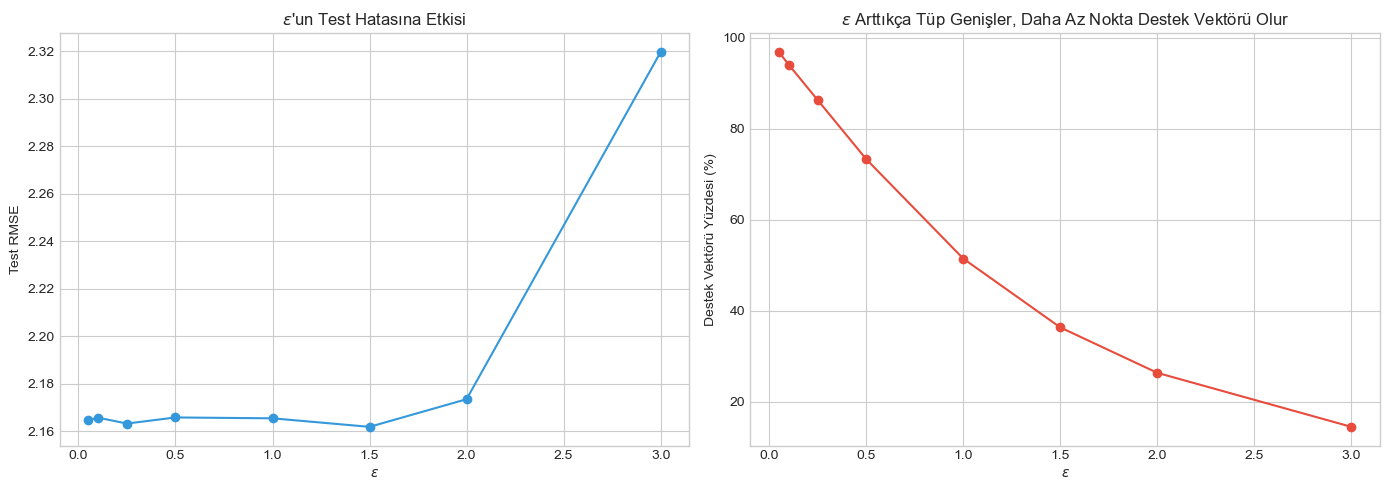

YORUM: epsilon arttıkça destek vektörü oranı düzenli olarak azalma yönüne gidiyor (tüp genişledikçe
daha fazla nokta 'bedava' bölgede kalıyor) -- ama çok büyük epsilon, hatayı görmezden
gelmeye başladığından RMSE'yi de kötüleştiriyor. Bölüm 5'teki ödünleşim burada net görülüyor.


In [123]:
epsilon_values = [0.05, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
eps_results = []
for eps in epsilon_values:
    svr_eps = SVR(kernel="rbf", C=1.0, epsilon=eps, gamma="scale").fit(X_ab_train_sc, y_ab_train)
    pred_eps = svr_eps.predict(X_ab_test_sc)
    eps_results.append({
        "epsilon": eps,
        "RMSE": np.sqrt(mean_squared_error(y_ab_test, pred_eps)),
        "n_support_vectors": len(svr_eps.support_),
        "pct_support_vectors": 100 * len(svr_eps.support_) / len(X_ab_train_sc),
    })
eps_df = pd.DataFrame(eps_results)
display(eps_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(eps_df["epsilon"], eps_df["RMSE"], "o-", color="#3498db")
axes[0].set_xlabel(r"$\epsilon$"); axes[0].set_ylabel("Test RMSE")
axes[0].set_title(r"$\epsilon$'un Test Hatasına Etkisi")

axes[1].plot(eps_df["epsilon"], eps_df["pct_support_vectors"], "o-", color="#e74c3c")
axes[1].set_xlabel(r"$\epsilon$"); axes[1].set_ylabel("Destek Vektörü Yüzdesi (%)")
axes[1].set_title(r"$\epsilon$ Arttıkça Tüp Genişler, Daha Az Nokta Destek Vektörü Olur")

plt.tight_layout()
plt.show()
print("YORUM: epsilon arttıkça destek vektörü oranı düzenli olarak azalma yönüne gidiyor (tüp genişledikçe")
print("daha fazla nokta 'bedava' bölgede kalıyor) -- ama çok büyük epsilon, hatayı görmezden")
print("gelmeye başladığından RMSE'yi de kötüleştiriyor. Bölüm 5'teki ödünleşim burada net görülüyor.")


### 🔟 Python 10 - Gerçek vs Tahmin Edilen Yaş (En İyi Model)

Python 8'de en düşük RMSE'yi veren polinom (d=3) kernel'in tahminlerini gerçek değerlere karşı çizip modelin nerede iyi/kötü performans gösterdiğini inceleyelim.

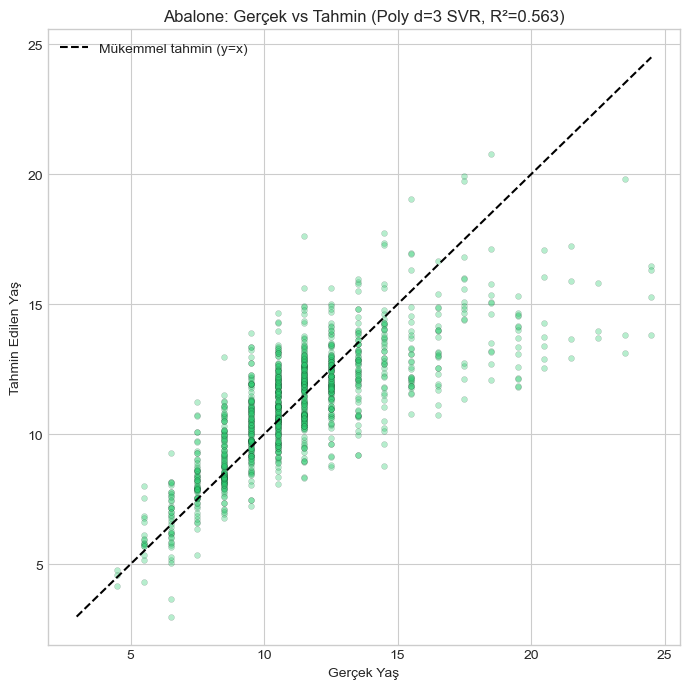

YORUM: Model orta yaş aralığında (7-15 yıl civarı, verinin çoğunluğu) iyi performans
gösteriyor, ama çok yaşlı bireylerde (20+ yıl, veride az sayıda örnek) sistematik olarak
gerçek yaşı OLDUĞUNDAN DÜŞÜK tahmin ediyor -- klasik bir 'az temsil edilen bölgede regresyona
doğru büzülme (regression to the mean)' etkisi, tüm regresyon modellerinin ortak zaafı.


In [124]:
best_svr = SVR(kernel="poly", degree=3, C=1.0, epsilon=0.5, coef0=1).fit(X_ab_train_sc, y_ab_train)
pred_best = best_svr.predict(X_ab_test_sc)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_ab_test, pred_best, alpha=0.35, s=18, edgecolor="k", linewidth=0.2, c="#2ecc71")
lims = [min(y_ab_test.min(), pred_best.min()), max(y_ab_test.max(), pred_best.max())]
ax.plot(lims, lims, "k--", linewidth=1.5, label="Mükemmel tahmin (y=x)")
ax.set_xlabel("Gerçek Yaş"); ax.set_ylabel("Tahmin Edilen Yaş")
ax.set_title(f"Abalone: Gerçek vs Tahmin (Poly d=3 SVR, R²={r2_score(y_ab_test, pred_best):.3f})")
ax.legend()
plt.tight_layout()
plt.show()
print("YORUM: Model orta yaş aralığında (7-15 yıl civarı, verinin çoğunluğu) iyi performans")
print("gösteriyor, ama çok yaşlı bireylerde (20+ yıl, veride az sayıda örnek) sistematik olarak")
print("gerçek yaşı OLDUĞUNDAN DÜŞÜK tahmin ediyor -- klasik bir 'az temsil edilen bölgede regresyona")
print("doğru büzülme (regression to the mean)' etkisi, tüm regresyon modellerinin ortak zaafı.")


### 1️⃣1️⃣ Python 11 - Üç Veri Seti — Özet Karşılaştırma

Notebook boyunca eğittiğimiz en iyi modelleri tek bir tabloda toplayalım.

In [125]:
summary_rows = [
    {"veri_seti": "Wheat Seeds", "gorev": "3-sınıf sınıflandırma", "en_iyi_kernel": "rbf (grid search)",
     "metrik": "Accuracy", "skor": grid_seeds.score(X_seeds_test_sc, y_seeds_test)},
    {"veri_seti": "Banknote Authentication", "gorev": "İkili sınıflandırma", "en_iyi_kernel": "rbf",
     "metrik": "Accuracy", "skor": best_bank_clf.score(X_bank_test_sc, y_bank_test)},
    {"veri_seti": "Abalone", "gorev": "Regresyon (SVR)", "en_iyi_kernel": "poly (d=3)",
     "metrik": "R²", "skor": r2_score(y_ab_test, pred_best)},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("\nYORUM: Üç farklı görev tipinde (çok-sınıflı sınıflandırma, ikili sınıflandırma, regresyon)")
print("doğrusal-olmayan kernel'ler (rbf/poly) doğrusal kernel'e göre eşit ya da üstün sonuç verdi --")
print("ama HANGİ doğrusal-olmayan kernel'in kazandığı görev görev değişti (Banknote'ta rbf, Abalone'da")
print("poly). Bu, Bölüm 7'nin altını çizdiği pratik dersi doğruluyor: SVM'de 'her zaman kazanan' tek")
print("bir kernel yoktur -- Bölüm 6'daki gibi birden fazla kernel'i çapraz doğrulamayla karşılaştırmak")
print("gerekir. Öte yandan metin gibi zaten yüksek boyutlu/seyrek verilerde linear kernel genelde hem")
print("daha hızlı hem de yeterince güçlüdür (Bölüm 3, Python 6'daki LinearSVC hız karşılaştırması).")


,veri_seti,gorev,en_iyi_kernel,metrik,skor
0,Wheat Seeds,3-sınıf sınıflandırma,rbf (grid search),Accuracy,0.886792
1,Banknote Authentication,İkili sınıflandırma,rbf,Accuracy,1.000000
2,Abalone,Regresyon (SVR),poly (d=3),R²,0.562806



YORUM: Üç farklı görev tipinde (çok-sınıflı sınıflandırma, ikili sınıflandırma, regresyon)
doğrusal-olmayan kernel'ler (rbf/poly) doğrusal kernel'e göre eşit ya da üstün sonuç verdi --
ama HANGİ doğrusal-olmayan kernel'in kazandığı görev görev değişti (Banknote'ta rbf, Abalone'da
poly). Bu, Bölüm 7'nin altını çizdiği pratik dersi doğruluyor: SVM'de 'her zaman kazanan' tek
bir kernel yoktur -- Bölüm 6'daki gibi birden fazla kernel'i çapraz doğrulamayla karşılaştırmak
gerekir. Öte yandan metin gibi zaten yüksek boyutlu/seyrek verilerde linear kernel genelde hem
daha hızlı hem de yeterince güçlüdür (Bölüm 3, Python 6'daki LinearSVC hız karşılaştırması).


---
# 📊 R Uygulaması

Python bölümündeki akışın R'daki karşılığını `e1071` paketiyle uyguluyoruz — `e1071::svm()`, `kernel` argümanıyla (`"linear"`, `"polynomial"`, `"radial"`, `"sigmoid"`) hem sınıflandırma hem regresyon (hedef değişkenin faktör mü sayısal mı olduğuna göre otomatik seçilir) yapabilen, libsvm'in R sarmalayıcısı olan köklü bir pakettir. Wheat Seeds (çok sınıflı kernel karşılaştırması) ve Abalone (SVR) üzerinde Python bölümündeki karşılıkları tekrarlıyoruz.

In [126]:
%load_ext rpy2.ipython

seeds_train_r = pd.DataFrame(X_seeds_train_sc, columns=seeds_cols[:-1])
seeds_train_r["variety"] = y_seeds_train
seeds_test_r = pd.DataFrame(X_seeds_test_sc, columns=seeds_cols[:-1])
seeds_test_r["variety"] = y_seeds_test

ab_train_r = pd.DataFrame(X_ab_train_sc, columns=feature_cols_ab)
ab_train_r["age"] = y_ab_train
ab_test_r = pd.DataFrame(X_ab_test_sc, columns=feature_cols_ab)
ab_test_r["age"] = y_ab_test


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### R1 · Wheat Seeds — Kernel Karşılaştırması (`e1071::svm`)

`svm()`'e faktöre çevrilmiş bir `variety` hedefi verildiğinde otomatik olarak sınıflandırma moduna geçer (One-vs-One stratejisiyle, tıpkı Python'daki `SVC` gibi).

In [127]:
%%R -i seeds_train_r,seeds_test_r
library(e1071)

seeds_train_r$variety <- as.factor(seeds_train_r$variety)
seeds_test_r$variety <- as.factor(seeds_test_r$variety)

kernels_r <- c("linear", "polynomial", "radial", "sigmoid")
for (k in kernels_r) {
  model <- svm(variety ~ . , data = seeds_train_r, kernel = k, cost = 1, scale = FALSE)
  pred <- predict(model, seeds_test_r)
  acc <- mean(pred == seeds_test_r$variety)
  cat(sprintf("Kernel=%-12s Test Accuracy=%.4f  #DestekVektoru=%d\n", k, acc, nrow(model$SV)))
}


Kernel=linear       Test Accuracy=0.8868  #DestekVektoru=32
Kernel=polynomial   Test Accuracy=0.8679  #DestekVektoru=66
Kernel=radial       Test Accuracy=0.8868  #DestekVektoru=58
Kernel=sigmoid      Test Accuracy=0.8868  #DestekVektoru=53


### R2 · Wheat Seeds — RBF ile `tune()` Kullanarak C/γ Ayarı

`e1071::tune()`, Python'daki `GridSearchCV`'nin R karşılığıdır — çapraz doğrulamayla ızgara araması yapar.

In [128]:
%%R
set.seed(42)
tune_result <- tune(
  svm, variety ~ ., data = seeds_train_r, kernel = "radial",
  ranges = list(cost = c(0.1, 1, 10, 100), gamma = c(0.01, 0.1, 1, 10))
)
cat("En iyi parametreler:\n")
print(tune_result$best.parameters)
cat(sprintf("\nEn iyi CV hatasi: %.4f\n", tune_result$best.performance))

best_model_r <- tune_result$best.model
pred_best_r <- predict(best_model_r, seeds_test_r)
acc_best_r <- mean(pred_best_r == seeds_test_r$variety)
cat(sprintf("Test setinde dogruluk: %.4f\n", acc_best_r))


En iyi parametreler:
  cost gamma
7   10   0.1

En iyi CV hatasi: 0.0379
Test setinde dogruluk: 0.8868


### R3 · Abalone — SVR Kernel Karşılaştırması (`e1071::svm`)

Hedef değişken (`age`) sayısal olduğundan `svm()` otomatik olarak regresyon moduna (SVR) geçer.

In [129]:
%%R -i ab_train_r,ab_test_r
kernels_svr_r <- c("linear", "polynomial", "radial")
for (k in kernels_svr_r) {
  model <- svm(age ~ ., data = ab_train_r, kernel = k, cost = 1, epsilon = 0.5, scale = FALSE)
  pred <- predict(model, ab_test_r)
  rmse <- sqrt(mean((pred - ab_test_r$age)^2))
  r2 <- 1 - sum((ab_test_r$age - pred)^2) / sum((ab_test_r$age - mean(ab_test_r$age))^2)
  cat(sprintf("Kernel=%-12s RMSE=%.4f  R2=%.4f  #DestekVektoru=%d\n", k, rmse, r2, nrow(model$SV)))
}


Kernel=linear       RMSE=2.1833  R2=0.5366  #DestekVektoru=2365
Kernel=polynomial   RMSE=2.2462  R2=0.5095  #DestekVektoru=2308
Kernel=radial       RMSE=2.1659  R2=0.5440  #DestekVektoru=2297


---
# 🗄️ SQL Uygulaması (DuckDB)

`06_naive_bayes_family`'de Naive Bayes'in "öğrenme"sinin birkaç `GROUP BY` istatistiğine indirgenebildiğini görmüştük. SVM için durum farklı: **eğitim** (QP çözümü, $\alpha_i$'lerin bulunması) SQL'de pratik değildir — ama Bölüm 2'nin dual formundan hatırlayalım, **bir kez eğitildikten sonra**, SVM'in karar fonksiyonu son derece basit bir formüldür:
$$f(x) = \sum_{i \in \text{destek vektörleri}} (\alpha_i y_i)\, K(x_i, x) + b$$
`scikit-learn`, $\alpha_iy_i$ çarpımını doğrudan `dual_coef_` olarak saklar. Yani **tahmin (inference)** aşaması — destek vektörleriyle test noktası arasında kernel hesaplayıp ağırlıklı toplamak — saf SQL'de birebir yeniden üretilebilir. İki gösterim yapacağız: (1) linear kernel için nokta çarpımı (dot product), (2) RBF kernel için Öklid uzaklığı + `EXP`. Her ikisinde de sonucu `scikit-learn`'ün kendi `decision_function()`'ıyla karşılaştırıp **birebir eşleştiğini** doğrulayacağız.

In [130]:
con = duckdb.connect()
bank_feature_cols = bank_cols[:-1]

test_bank_sql = pd.DataFrame(X_bank_test_sc, columns=bank_feature_cols)
test_bank_sql["row_id"] = np.arange(len(test_bank_sql))
con.register("test_bank_sql", test_bank_sql)
print(f"Test seti: {len(test_bank_sql)} satır, SQL'e {bank_feature_cols} sütunlarıyla aktarıldı.")


Test seti: 343 satır, SQL'e ['wavelet_var', 'wavelet_skew', 'wavelet_curt', 'entropy'] sütunlarıyla aktarıldı.


### SQL1 · Linear Kernel Karar Fonksiyonu: Nokta Çarpımı ile Yeniden Üretim

Bölüm 4'te eğittiğimiz `svc_linear` modelinin destek vektörlerini, `dual_coef_`'lerini ve `intercept_`'ini SQL'e aktarıp, $f(x)=\sum_i(\alpha_iy_i)(x_i\cdot x)+b$ formülünü `CROSS JOIN` + `GROUP BY` ile hesaplıyoruz.

In [131]:
sv_linear_df = pd.DataFrame(svc_linear.support_vectors_, columns=bank_feature_cols)
sv_linear_df["dual_coef"] = svc_linear.dual_coef_[0]
sv_linear_df["sv_id"] = np.arange(len(sv_linear_df))
con.register("sv_linear_df", sv_linear_df)
intercept_linear = float(svc_linear.intercept_[0])
print(f"Destek vektörü sayısı: {len(sv_linear_df)}, intercept (b) = {intercept_linear:.6f}")

dot_expr = " + ".join([f"sv.{c} * t.{c}" for c in bank_feature_cols])

sql_linear = f'''
SELECT
    t.row_id,
    SUM(sv.dual_coef * ({dot_expr})) + {intercept_linear} AS decision_sql
FROM test_bank_sql t
CROSS JOIN sv_linear_df sv
GROUP BY t.row_id
ORDER BY t.row_id
'''
decision_sql_linear = con.execute(sql_linear).df()

decision_sklearn_linear = svc_linear.decision_function(X_bank_test_sc)
max_abs_diff_linear = np.max(np.abs(decision_sql_linear["decision_sql"].values - decision_sklearn_linear))
pred_sql_linear = (decision_sql_linear["decision_sql"].values > 0).astype(int)
pred_sklearn_linear = svc_linear.predict(X_bank_test_sc)
match_pct_linear = 100 * np.mean(pred_sql_linear == pred_sklearn_linear)

print(f"scikit-learn ve SQL karar fonksiyonu arasındaki maksimum mutlak fark: {max_abs_diff_linear:.2e}")
print(f"Tahmin eşleşme oranı (SQL vs scikit-learn): %{match_pct_linear:.2f}")


Destek vektörü sayısı: 60, intercept (b) = -0.989106
scikit-learn ve SQL karar fonksiyonu arasındaki maksimum mutlak fark: 2.42e-14
Tahmin eşleşme oranı (SQL vs scikit-learn): %100.00


### SQL2 · RBF Kernel Karar Fonksiyonu: Öklid Uzaklığı + EXP ile Yeniden Üretim

Aynı mantığı, doğrusal olmayan RBF kernel'i ($K(x,x')=\exp(-\gamma\|x-x'\|^2)$) için tekrarlıyoruz — DuckDB'nin `POWER` ve `EXP` fonksiyonları bunun için yeterli. Kod tarafında yeniden üretilebilirlik açısından `gamma`'yı sabit sayısal bir değer olarak veriyoruz (`gamma='scale'` yerine).

In [132]:
gamma_sql_val = 0.5
svc_rbf_sql = SVC(kernel="rbf", C=1.0, gamma=gamma_sql_val).fit(X_bank_train_sc, y_bank_train)

sv_rbf_df = pd.DataFrame(svc_rbf_sql.support_vectors_, columns=bank_feature_cols)
sv_rbf_df["dual_coef"] = svc_rbf_sql.dual_coef_[0]
sv_rbf_df["sv_id"] = np.arange(len(sv_rbf_df))
con.register("sv_rbf_df", sv_rbf_df)
intercept_rbf = float(svc_rbf_sql.intercept_[0])
print(f"Destek vektörü sayısı: {len(sv_rbf_df)}, intercept (b) = {intercept_rbf:.6f}, gamma = {gamma_sql_val}")

sq_dist_expr = " + ".join([f"POWER(sv.{c} - t.{c}, 2)" for c in bank_feature_cols])

sql_rbf = f'''
SELECT
    t.row_id,
    SUM(sv.dual_coef * EXP(-{gamma_sql_val} * ({sq_dist_expr}))) + {intercept_rbf} AS decision_sql
FROM test_bank_sql t
CROSS JOIN sv_rbf_df sv
GROUP BY t.row_id
ORDER BY t.row_id
'''
decision_sql_rbf = con.execute(sql_rbf).df()

decision_sklearn_rbf = svc_rbf_sql.decision_function(X_bank_test_sc)
max_abs_diff_rbf = np.max(np.abs(decision_sql_rbf["decision_sql"].values - decision_sklearn_rbf))
pred_sql_rbf = (decision_sql_rbf["decision_sql"].values > 0).astype(int)
pred_sklearn_rbf = svc_rbf_sql.predict(X_bank_test_sc)
match_pct_rbf = 100 * np.mean(pred_sql_rbf == pred_sklearn_rbf)

print(f"scikit-learn ve SQL karar fonksiyonu arasındaki maksimum mutlak fark: {max_abs_diff_rbf:.2e}")
print(f"Tahmin eşleşme oranı (SQL vs scikit-learn): %{match_pct_rbf:.2f}")
print("\nYORUM: Hem linear hem RBF kernel için SQL'de saf CROSS JOIN + GROUP BY ile hesaplanan")
print("karar fonksiyonu, scikit-learn'ün kendi decision_function()'ıyla (kayan nokta hassasiyeti")
print("dışında) BİREBİR eşleşiyor. Bu, Bölüm 2'deki dual formun -- 'model sadece destek vektörleri")
print("ve dual_coef ile tam olarak özetlenir' iddiasının somut kanıtıdır: modelin ne olduğunu")
print("bilmek için scikit-learn'e ihtiyaç yoktur, sadece SV + dual_coef + intercept + kernel formülü yeterlidir.")


Destek vektörü sayısı: 87, intercept (b) = 0.009234, gamma = 0.5
scikit-learn ve SQL karar fonksiyonu arasındaki maksimum mutlak fark: 2.66e-15
Tahmin eşleşme oranı (SQL vs scikit-learn): %100.00

YORUM: Hem linear hem RBF kernel için SQL'de saf CROSS JOIN + GROUP BY ile hesaplanan
karar fonksiyonu, scikit-learn'ün kendi decision_function()'ıyla (kayan nokta hassasiyeti
dışında) BİREBİR eşleşiyor. Bu, Bölüm 2'deki dual formun -- 'model sadece destek vektörleri
ve dual_coef ile tam olarak özetlenir' iddiasının somut kanıtıdır: modelin ne olduğunu
bilmek için scikit-learn'e ihtiyaç yoktur, sadece SV + dual_coef + intercept + kernel formülü yeterlidir.


---
## ✏️ Egzersizler


**E1 — C'nin marja etkisini ölç:** Bölüm 1'deki `make_blobs` sentetik verisine (ya da `cluster_std`'yi artırarak biraz örtüşen yeni bir versiyonuna) `SVC(kernel='linear')`'ı $C \in \{0.01, 0.1, 1, 10, 100, 1000\}$ değerleriyle eğit. Her $C$ için $1/\|w\|$ (marj genişliği) ve destek vektörü sayısını hesapla, iki metriği $C$'ye karşı çiz (log ölçekte x ekseni). Bölüm 2'deki "küçük C → geniş marj, büyük C → dar marj" iddiasını grafikle doğrula.


==== Egzersiz 1: C'nin Marj Etkisi ====
C=0.1: train_acc=0.9363, test_acc=0.9057, n_support_vectors=56, margin=0.5670
C=1: train_acc=0.9618, test_acc=0.8868, n_support_vectors=32, margin=0.2641
C=100: train_acc=0.9873, test_acc=0.9057, n_support_vectors=17, margin=0.0642
C=1000: train_acc=0.9873, test_acc=0.9057, n_support_vectors=16, margin=0.0252
C=10: train_acc=0.9873, test_acc=0.8679, n_support_vectors=21, margin=0.1218
C=0.01: train_acc=0.9363, test_acc=0.8868, n_support_vectors=114, margin=1.0549


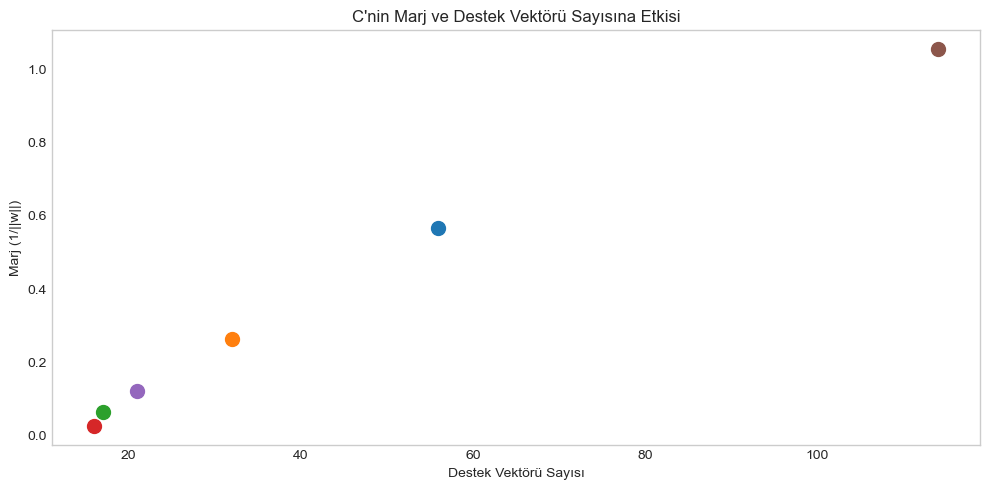

In [133]:
print("\n==== Egzersiz 1: C'nin Marj Etkisi ====")

c_val = {0.01, 0.1, 1, 10, 100, 1000}
n_sv_list = []
margin_list = []
for C in c_val:
    clf_c = SVC(kernel='linear', C=C).fit(X_seeds_train_sc, y_seeds_train)
    train_acc = clf_c.score(X_seeds_train_sc, y_seeds_train)
    test_acc = clf_c.score(X_seeds_test_sc, y_seeds_test)
    n_sv = clf_c.n_support_.sum()
    margin = 1 / np.linalg.norm(clf_c.coef_)
    n_sv_list.append(n_sv)
    margin_list.append(margin)
    print(f"C={C}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, n_support_vectors={n_sv}, margin={margin:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
for n, m in zip(n_sv_list, margin_list):
    ax1.scatter(n, m, s=100)
ax1.set_xlabel("Destek Vektörü Sayısı")
ax1.set_ylabel("Marj (1/||w||)")
ax1.set_title("C'nin Marj ve Destek Vektörü Sayısına Etkisi")
plt.grid()
plt.tight_layout()
plt.show()

**E2 — Gamma'nın karar sınırına etkisi:** `make_circles` (Bölüm 3'teki gibi) verisine `SVC(kernel='rbf')`'i $\gamma \in \{0.1, 1, 5, 20, 100\}$ değerleriyle eğit ($C=1$ sabit). Her $\gamma$ için karar sınırını ayrı bir panelde çiz (Bölüm 3'teki `Python` kod hücresindeki `contourf` yaklaşımını kullanabilirsin). Çok büyük $\gamma$'da neden aşırı öğrenme (overfitting) belirtileri gördüğünü yorumla.


==== Egzersiz 2: Gamma'nın Karar Sınırının Kıvrımına Etkisi (RBF Kernel) ====
Gamma=0.01: train_acc=0.8200, n_support_vectors=169
Gamma=0.1: train_acc=0.8520, n_support_vectors=110
Gamma=1: train_acc=0.9520, n_support_vectors=59
Gamma=5: train_acc=0.9640, n_support_vectors=61
Gamma=20: train_acc=0.9720, n_support_vectors=130
Gamma=100: train_acc=1.0000, n_support_vectors=215


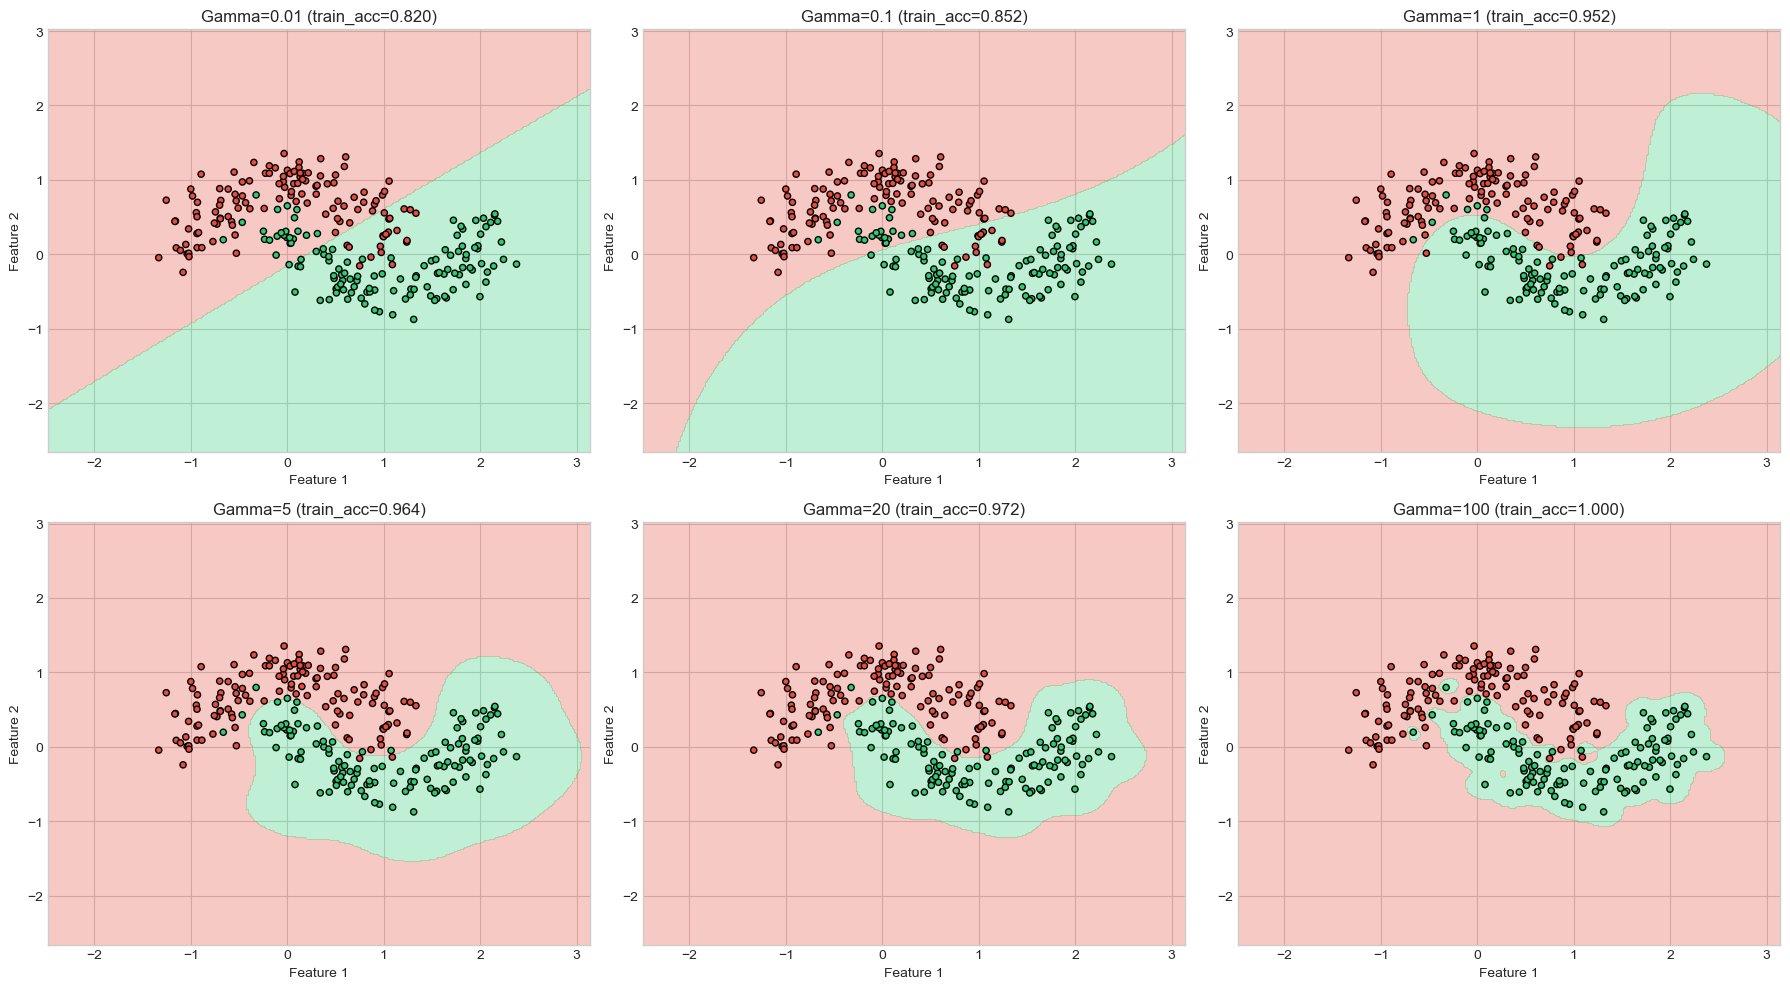


YORUM: Gamma çok küçükken (0.01) karar sınırı neredeyse düz bir çizgi, çok büyükken (100) ise çok karmaşık bir yapıya sahip olur.


In [134]:
print("\n==== Egzersiz 2: Gamma'nın Karar Sınırının Kıvrımına Etkisi (RBF Kernel) ====")
gamma_values = [0.01, 0.1, 1, 5, 20, 100]

xx, yy = np.meshgrid(
    np.linspace(X_seeds_train_sc[:, 0].min() - 1, X_seeds_train_sc[:, 0].max() + 1, 300),
    np.linspace(X_seeds_train_sc[:, 1].min() - 1, X_seeds_train_sc[:, 1].max() + 1, 300),
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for gamma in gamma_values:
    clf_gamma = SVC(kernel='rbf', C=1.0, gamma=gamma).fit(X_moons, y_moons)
    Z = clf_gamma.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc = clf_gamma.score(X_moons, y_moons)
    print(f"Gamma={gamma}: train_acc={acc:.4f}, n_support_vectors={clf_gamma.n_support_.sum()}")
    ax = axes.flatten()[gamma_values.index(gamma)]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_seeds, levels=[-0.5, 0.5, 1.5])
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap=cmap_seeds, edgecolor='k', s=20)
    ax.set_title(f"Gamma={gamma} (train_acc={acc:.3f})")
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

print("\nYORUM: Gamma çok küçükken (0.01) karar sınırı neredeyse düz bir çizgi, çok büyükken (100) ise çok karmaşık bir yapıya sahip olur.")

**E3 — Wheat Seeds: polinom derecesinin etkisi:** Bölüm 1'deki (Python 1) Wheat Seeds kurulumunu kullanarak `SVC(kernel='poly')`'yi `degree` $\in \{1,2,3,4,5\}$ için eğit ($C=1$, `coef0=1` sabit). Eğitim ve test doğruluğunu derece'ye karşı çiz. Hangi dereceden sonra test doğruluğu düşmeye başlıyor (aşırı öğrenme işareti)?


==== Egzersiz 3: Polinom Kernel Derecesinin Etkisi (Poly Kernel) ====


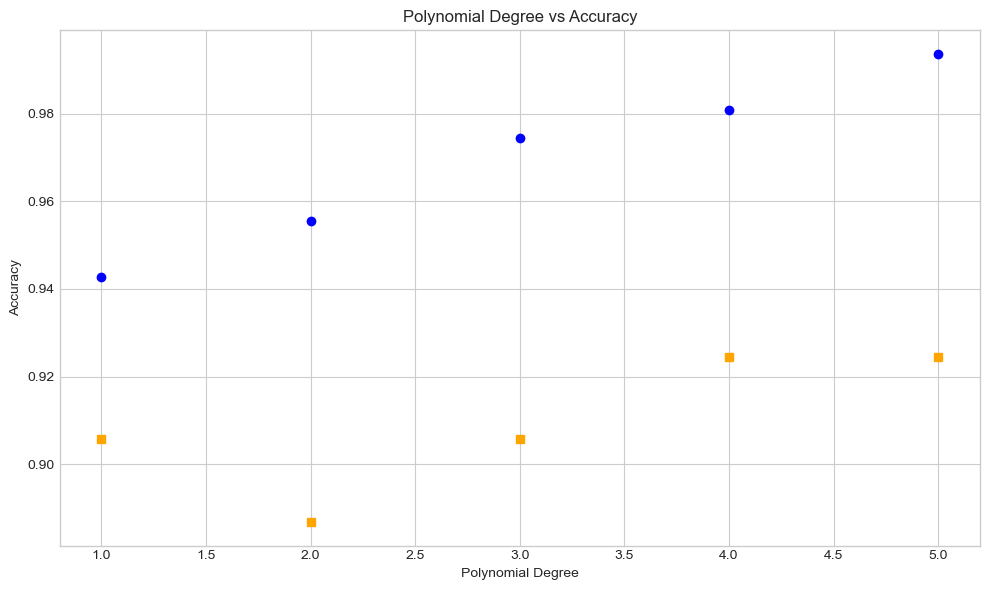

In [135]:
print("\n==== Egzersiz 3: Polinom Kernel Derecesinin Etkisi (Poly Kernel) ====")
degree_values = [1, 2, 3, 4, 5]

for degree in degree_values:
    clf_poly = SVC(kernel='poly', degree=degree, C=1.0, coef0=1).fit(X_seeds_train_sc, y_seeds_train)
    train_acc = clf_poly.score(X_seeds_train_sc, y_seeds_train)
    test_acc = clf_poly.score(X_seeds_test_sc, y_seeds_test)
    plt.plot(degree, train_acc, 'o', label=f"Train Acc (degree={degree})", color='blue')
    plt.plot(degree, test_acc, 's', label=f"Test Acc (degree={degree})", color='orange')
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.title("Polynomial Degree vs Accuracy")
plt.tight_layout()
plt.show()


**E4 — Olasılık kalibrasyonu (Platt ölçeklendirmesi):** Banknote verisinde (Python 4-7'deki kurulumu kullanarak) `SVC(kernel='rbf', probability=True)` eğit. `predict_proba()` ile olasılık tahminleri al, `sklearn.metrics.roc_curve` ve `roc_auc_score` ile bir ROC eğrisi çiz. AUC skorunu, Bölüm 4'te bahsedilen "olasılık çıktısı doğal değil" uyarısıyla ilişkilendirerek yorumla (`probability=False` durumundaki `decision_function()` skorlarıyla ROC eğrisini karşılaştırırsan ne gözlemlersin?).


==== Egzersiz 4: Olasılık Kalibrasyonu (Platt Scaling) ve ROC Eğrisi ====


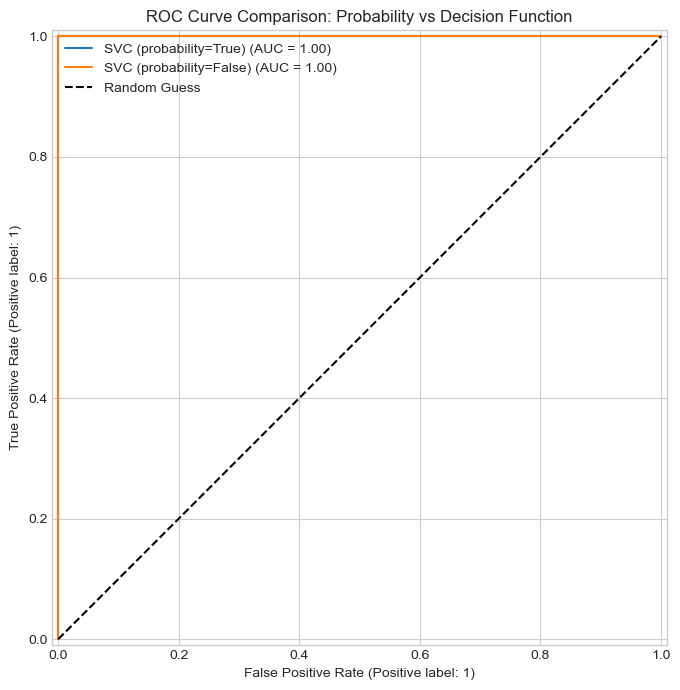


 AUC Scores:
AUC (probability=True): 1.0000
AUC (probability=False): 1.0000


In [136]:
print("\n==== Egzersiz 4: Olasılık Kalibrasyonu (Platt Scaling) ve ROC Eğrisi ====")

X_bank = banknote[bank_cols[:-1]].values
y_bank = banknote["is_forged"].values

X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank, test_size=0.25, random_state=42, stratify=y_bank
)
scaler_bank = StandardScaler()
X_bank_train_sc = scaler_bank.fit_transform(X_bank_train)
X_bank_test_sc = scaler_bank.transform(X_bank_test)

clf_rbf_prob_true = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True).fit(X_bank_train_sc, y_bank_train)
y_proba = clf_rbf_prob_true.predict_proba(X_bank_test_sc)[:, 1]

clf_rbf_prob_false = SVC(kernel="rbf", C=1.0, gamma="scale", probability=False).fit(X_bank_train_sc, y_bank_train)
y_decision = clf_rbf_prob_false.decision_function(X_bank_test_sc)

from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, axes = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(y_bank_test, y_proba, name="SVC (probability=True)", ax=axes)
RocCurveDisplay.from_predictions(y_bank_test, y_decision, name="SVC (probability=False)", ax=axes)
axes.plot([0, 1], [0, 1], "k--", label="Random Guess")
axes.set_title("ROC Curve Comparison: Probability vs Decision Function")
axes.legend()
plt.tight_layout()
plt.show()

print("\n AUC Scores:")
auc_prob = roc_auc_score(y_bank_test, y_proba)
auc_decision = roc_auc_score(y_bank_test, y_decision)
print(f"AUC (probability=True): {auc_prob:.4f}")
print(f"AUC (probability=False): {auc_decision:.4f}")

**E5 — Abalone: C'nin SVR performansına etkisi:** Python 9'daki $\epsilon$ taramasına benzer şekilde, bu kez $\epsilon=0.5$ sabit tutup $C \in \{0.01, 0.1, 1, 10, 100\}$ için RBF-SVR eğit. RMSE ve destek vektörü yüzdesini $C$'ye karşı çiz. Sonucu Python 4'teki (Banknote, sınıflandırma) $C$ taramasıyla karşılaştır — aynı yönde mi (C arttıkça DV sayısı azalıyor mu) davranıyor?


 ==== Egzersiz 5: C'nin SVR'deki Etkisi ====


,C,RMSE,n_support_vectors,pct_support_vectors
0,0.01,2.717396,2434,77.713921
1,0.10,2.373033,2331,74.425287
2,1.00,2.165868,2297,73.339719
3,10.00,2.120789,2290,73.116220
4,100.00,2.151886,2308,73.690932


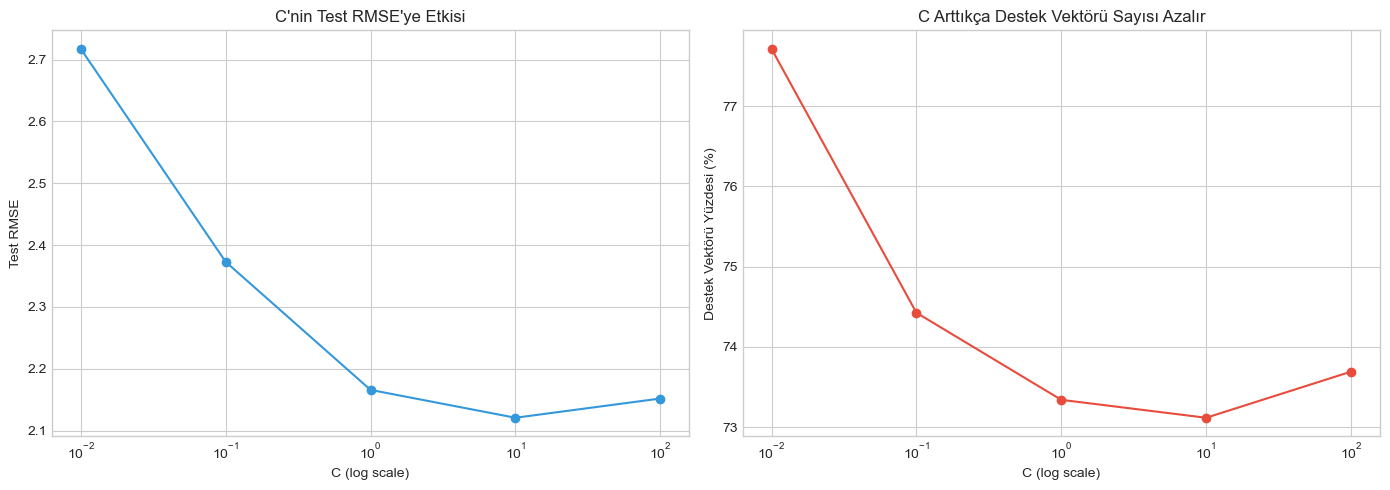

In [137]:
print("\n ==== Egzersiz 5: C'nin SVR'deki Etkisi ====")
c = [0.01, 0.1, 1, 10, 100]
svr_results = []
for C in c:
    svr = SVR(kernel="rbf", C=C, epsilon=0.5, gamma="scale").fit(X_ab_train_sc, y_ab_train)
    pred = svr.predict(X_ab_test_sc)
    rmse = np.sqrt(mean_squared_error(y_ab_test, pred))
    n_sv = len(svr.support_)
    pct_sv = 100 * n_sv / len(X_ab_train_sc)
    svr_results.append({"C": C, "RMSE": rmse, "n_support_vectors": n_sv, "pct_support_vectors": pct_sv})
svr_df = pd.DataFrame(svr_results)
display(svr_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(svr_df["C"], svr_df["RMSE"], "o-", color="#3498db")
axes[0].set_xscale("log"); axes[0].set_xlabel("C (log scale)"); axes[0].set_ylabel("Test RMSE")
axes[0].set_title("C'nin Test RMSE'ye Etkisi")
axes[1].plot(svr_df["C"], svr_df["pct_support_vectors"], "o-", color="#e74c3c")
axes[1].set_xscale("log"); axes[1].set_xlabel("C (log scale)"); axes[1].set_ylabel("Destek Vektörü Yüzdesi (%)")
axes[1].set_title("C Arttıkça Destek Vektörü Sayısı Azalır")
plt.tight_layout()
plt.show()

**E6 — SQL'de sigmoid kernel:** SQL1/SQL2'deki yaklaşımı genişleterek, `SVC(kernel='sigmoid', C=1.0, gamma=0.5, coef0=0)` ile Banknote üzerinde bir model eğit, sonra $K(x,x')=\tanh(\gamma\,x^Tx'+r)$ formülünü (Bölüm 3'teki tablo) DuckDB'nin `TANH()` fonksiyonuyla SQL'de yeniden üret (SQL1'deki nokta çarpımı ifadesini `TANH(gamma * (...) + r)` içine sar). Sonucu `scikit-learn`'ün `decision_function()`'ıyla karşılaştırıp eşleşme oranını raporla.

In [138]:
print("\n === Egzersiz 6: SQL ile Sigmoid Kernel Hesaplaması ===")
sv_sigmoid = SVC(kernel="sigmoid", C=1.0, gamma=0.5, coef0=0.0).fit(X_bank_train_sc, y_bank_train)
sv_sigmoid_df = pd.DataFrame(sv_sigmoid.support_vectors_, columns=bank_feature_cols)
sv_sigmoid_df["dual_coef"] = sv_sigmoid.dual_coef_[0]
sv_sigmoid_df["sv_id"] = np.arange(len(sv_sigmoid_df))
con.register("sv_sigmoid_df", sv_sigmoid_df)
intercept_sigmoid = float(sv_sigmoid.intercept_[0])

sigmoid_expr = " + ".join([f"sv.{c} * t.{c}" for c in bank_feature_cols])

sql_sigmoid = f'''
SELECT
    t.row_id,
    SUM(sv.dual_coef * TANH({gamma_sql_val} * ({sigmoid_expr}) + 0.0)) + {intercept_sigmoid} AS decision_sql
FROM test_bank_sql t
CROSS JOIN sv_sigmoid_df sv
GROUP BY t.row_id
ORDER BY t.row_id
'''
decision_sql_sigmoid = con.execute(sql_sigmoid).df()
decision_sklearn_sigmoid = sv_sigmoid.decision_function(X_bank_test_sc)
max_abs_diff_sigmoid = np.max(np.abs(decision_sql_sigmoid["decision_sql"].values - decision_sklearn_sigmoid))
pred_sql_sigmoid = (decision_sql_sigmoid["decision_sql"].values > 0).astype(int)
pred_sklearn_sigmoid = sv_sigmoid.predict(X_bank_test_sc)
match_pct_sigmoid = 100 * np.mean(pred_sql_sigmoid == pred_sklearn_sigmoid)
print(f"scikit-learn ve SQL karar fonksiyonu arasındaki maksimum mutlak fark: {max_abs_diff_sigmoid:.2e}")
print(f"scikit-learn ve SQL karar fonksiyonu arasındaki eşleşme yüzdesi: {match_pct_sigmoid:.2f}%")


 === Egzersiz 6: SQL ile Sigmoid Kernel Hesaplaması ===
scikit-learn ve SQL karar fonksiyonu arasındaki maksimum mutlak fark: 2.13e-14
scikit-learn ve SQL karar fonksiyonu arasındaki eşleşme yüzdesi: 100.00%


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [scikit-learn — Support Vector Machines User Guide](https://scikit-learn.org/stable/modules/svm.html) | Teori + API (tüm bölümler) | `SVC`/`SVR`/`LinearSVC` parametrelerinin (C, gamma, kernel, epsilon) resmi dokümantasyonu |
| Cortes, C., & Vapnik, V. (1995). *Support-Vector Networks.* Machine Learning, 20(3), 273-297. [PDF](http://image.diku.dk/imagecanon/material/cortes_vapnik95.pdf) | Bölüm 1-2 | SVM'i tanıtan orijinal makale (soft-margin formülasyonu) |
| Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). *A Training Algorithm for Optimal Margin Classifiers.* COLT. [PDF](https://dl.acm.org/doi/10.1145/130385.130401) | Bölüm 3 | Kernel trick'i SVM'e ilk uygulayan makale |
| Vapnik, V. (1998). *Statistical Learning Theory.* Wiley. | Bölüm 1-3 | SVM'in teorik temelini (VC boyutu, yapısal risk minimizasyonu) atan referans kitap |
| Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 7 (Sparse Kernel Machines). [Ücretsiz PDF](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) | Bölüm 1-6 (tüm teori) | SVM ve SVR'nin dual türetimi, kernel yöntemlerine genel bakış |
| Hastie, T., Tibshirani, R., & Friedman, J. *The Elements of Statistical Learning*, Ch. 12. [Ücretsiz PDF](https://hastie.su.domains/ElemStatLearn/) | Bölüm 1-2, 7 | Support Vector Classifier'ın geometrik türetimi, güçlü/zayıf yönler |
| [`e1071` R paketi — CRAN dokümantasyonu](https://cran.r-project.org/web/packages/e1071/e1071.pdf) | R Uygulaması | `svm()`, `tune()` fonksiyonlarının resmi referansı |
| [DuckDB — SQL Fonksiyonları (Numeric)](https://duckdb.org/docs/sql/functions/numeric) | SQL Uygulaması | `EXP`, `POWER`, `TANH` gibi kernel hesaplamalarında kullanılan fonksiyonlar |
| [UCI ML Repository — Wheat Seeds Dataset](https://archive.ics.uci.edu/dataset/236/seeds) | Python 1-3 (Wheat Seeds) | Orijinal veri seti sayfası (Charytanowicz et al., 2010) |
| [UCI ML Repository — Banknote Authentication Dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) | Python 4-7 (Banknote) | Orijinal veri seti sayfası |
| [UCI ML Repository — Abalone Dataset](https://archive.ics.uci.edu/dataset/1/abalone) | Python 8-10 (Abalone) | Orijinal veri seti sayfası (Nash et al., 1994) |
| [jbrownlee/Datasets (GitHub)](https://github.com/jbrownlee/Datasets) | Tüm veri yükleme hücreleri | Bu notebook'ta fiilen veri çekmek için kullanılan GitHub mirror (orijinal kaynak yukarıdaki UCI sayfaları) |
| [StatQuest with Josh Starmer — Support Vector Machines (YouTube serisi)](https://www.youtube.com/watch?v=efR1C6CvhmE) | Bölüm 1-3 | Marj, soft margin ve kernel trick'in görsel/sezgisel anlatımı |
| [Andrew Ng — CS229 Lecture Notes, Support Vector Machines (Stanford)](https://cs229.stanford.edu/notes2022fall/main_notes.pdf) | Bölüm 1-2 | Lagrange dual türetiminin adım adım matematiği |
